In [2]:
from dataclasses import replace
from pathlib import Path

from realistic_chan_simulation import (
    RealisticSimulationConfig,
    run_realistic_simulation,
    print_simulation_summary,
)

config = RealisticSimulationConfig()

config = replace(
    config,
    data_path=Path("DataAPI/data/TQQQ_5M.csv"),
    bsp_workbook_path=Path(
        "outputs/bspoints_TQQQ_5m_2020-2026.xlsx"
    ),
    replay_mode="regenerate",

    chan=replace(
        config.chan,
        code="TQQQ",
        trigger_step=True,
        start="2020-01-01",
        end="2026-05-30",
        warmup_bars=500,
        max_klines=500,
    ),

    risk=replace(
        config.risk,
        stop_loss_pct=0.10,
        take_profit_pct=0.15,
        trailing_stop_pct=0.15,
        max_holding_bars=78 * 10,
    ),

    backtest=replace(
        config.backtest,
        initial_capital=100_000,
        fee_pct=0.0,
        slippage_pct=0.0,
    ),
)

In [ ]:
from dataclasses import replace
from pathlib import Path

from realistic_chan_simulation import (
    RealisticSimulationConfig,
    run_realistic_simulation,
    print_simulation_summary,
)

config = RealisticSimulationConfig()

config = replace(
    config,
    data_path=Path("DataAPI/data/TQQQ_5M.csv"),
    bsp_workbook_path=Path(
        "outputs/bspoints_TQQQ_5m_2020-2026.xlsx"
    ),
    replay_mode="regenerate",

    chan=replace(
        config.chan,
        code="TQQQ",
        trigger_step=True,
        start="2020-01-01",
        end="2026-05-30",
        warmup_bars=500,
        max_klines=500,
    ),

    risk=replace(
        config.risk,
        stop_loss_pct=0.10,
        take_profit_pct=0.15,
        trailing_stop_pct=0.15,
        max_holding_bars=78 * 10,
    ),

    backtest=replace(
        config.backtest,
        initial_capital=100_000,
        fee_pct=0.0,
        slippage_pct=0.0,
    ),
)

output = run_realistic_simulation(config)

print_simulation_summary(output)

In [ ]:
# strategy_config = replace(
#     config.strategy,

#     buy_lookback_bars_by_segment={
#         "up": 10,
#         "down": 20,
#     },

#     required_buy_signals_by_segment={
#         "up": {
#             "1": 1,
#             "1p": 1,
#             "2": 1,
#             "2s": 1,
#             "3a": 2,
#             "3b": 2,
#         },
#         "down": {
#             "1": 7,
#             "1p": 7,
#             "2": 5,
#             "2s": 5,
#             "3a": 12,
#             "3b": 12,
#         },
#     },

#     sell_lookback_bars_by_entry_segment={
#         "up": 20,
#         "down": 10,
#     },

#     required_sell_signals_by_entry_segment={
#         "up": {
#             "1": 15,
#             "1p": 15,
#             "2": 15,
#             "2s": 15,
#             "3a": 15,
#             "3b": 15,
#         },
#         "down": {
#             "1": 1,
#             "1p": 1,
#             "2": 1,
#             "2s": 1,
#             "3a": 1,
#             "3b": 1,
#         },
#     },
# )


In [ ]:
from realistic_chan_simulation import (
    RealisticSimulationConfig,
    run_realistic_simulation,
    print_simulation_summary,
)
import pandas as pd
import matplotlib.pyplot as plt

result = output.result

# Summary printed as text
print_simulation_summary(output)

# Metrics table
metrics_df = pd.DataFrame(
    result.metrics.items(),
    columns=["metric", "value"],
)

display(metrics_df)

# All buy and sell fills
display(result.trades)

# Most recent equity rows
display(result.equity.tail(20))

Price rows: 306,208
Chan feed rows (including warmup): 306,708
Point-in-time BSP events: 39,222
Simulation period: 2020-01-02 04:00:00 to 2026-05-29 19:55:00

Strategy metrics:
final_equity: 200421.54849375944
total_return: 1.0042154849375944
max_drawdown: -0.6783461721773218
sharpe: 0.29850710744206577
closed_trades: 1291
win_rate: 0.5189775367931836
profit_factor: 1.0820714637114521


,metric,value
0,final_equity,200421.548494
1,total_return,1.004215
2,max_drawdown,-0.678346
3,sharpe,0.298507
4,closed_trades,1291.000000
5,win_rate,0.518978
6,profit_factor,1.082071


,side,seen_idx,exec_idx,exec_px,reason,position_fraction,idx,px,raw_px,qty,fee,pnl,return_pct
0,buy,383,384,10.8125,1/1 type-2 buy-signal bars in 10-bar window; B...,1.0,384,10.8125,10.8125,9248.554913,0.0,NaN,NaN
1,sell,421,422,10.7812,entry segment up; exit segment down,1.0,422,10.7812,10.7812,9248.554913,0.0,-289.479769,-0.002895
2,buy,705,706,10.7900,5/5 type-1 buy-signal bars in 15-bar window; B...,1.0,706,10.7900,10.7900,9241.012070,0.0,NaN,NaN
3,sell,790,791,11.3513,1/1 type-1 sell-signal bars in 10-bar window i...,1.0,791,11.3513,11.3513,9241.012070,0.0,5186.980075,0.052020
4,buy,801,802,11.2500,1/1 type-2s buy-signal bars in 10-bar window; ...,1.0,802,11.2500,11.2500,9324.222249,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2577,sell,304422,304423,76.0500,entry segment up; exit segment down,1.0,304423,76.0500,76.0500,2594.089181,0.0,259.408918,0.001317
2578,buy,304430,304431,75.3600,5/5 type-2s buy-signal bars in 15-bar window; ...,1.0,304431,75.3600,75.3600,2617.840794,0.0,NaN,NaN
2579,sell,304886,304887,74.5400,1/1 type-1p sell-signal bars in 10-bar window ...,1.0,304887,74.5400,74.5400,2617.840794,0.0,-2146.629451,-0.010881
2580,buy,305081,305082,76.3900,1/1 type-2 buy-signal bars in 10-bar window; B...,1.0,305082,76.3900,76.3900,2554.442372,0.0,NaN,NaN


,timestamp,bar_index,equity,position
306188,2026-05-29 18:20:00,306188,200421.548494,0
306189,2026-05-29 18:25:00,306189,200421.548494,0
306190,2026-05-29 18:30:00,306190,200421.548494,0
306191,2026-05-29 18:35:00,306191,200421.548494,0
306192,2026-05-29 18:40:00,306192,200421.548494,0
306193,2026-05-29 18:45:00,306193,200421.548494,0
306194,2026-05-29 18:50:00,306194,200421.548494,0
306195,2026-05-29 18:55:00,306195,200421.548494,0
306196,2026-05-29 19:00:00,306196,200421.548494,0
306197,2026-05-29 19:05:00,306197,200421.548494,0


In [ ]:
from pathlib import Path
import pandas as pd

excel_path = Path(
    "outputs/strategy_backtest/TQQQ_realistic_strategy_2_result.xlsx"
)

excel_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

metrics_df = pd.DataFrame(
    output.result.metrics.items(),
    columns=["metric", "value"],
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl",
) as writer:
    metrics_df.to_excel(
        writer,
        sheet_name="Metrics",
        index=False,
    )

    output.result.trades.to_excel(
        writer,
        sheet_name="Fills",
        index=False,
    )

    output.result.equity.to_excel(
        writer,
        sheet_name="Equity",
        index=False,
    )

    output.bsp_df.to_excel(
        writer,
        sheet_name="BSP Points",
        index=False,
    )

    output.price_df.to_excel(
        writer,
        sheet_name="Price Data",
        index=False,
    )

print(f"Saved Excel workbook to:\n{excel_path.resolve()}")

Saved Excel workbook to:
C:\Users\TonyTang\Documents\chan.py\outputs\strategy_backtest\TQQQ_realistic_strategy_2_result.xlsx


: 

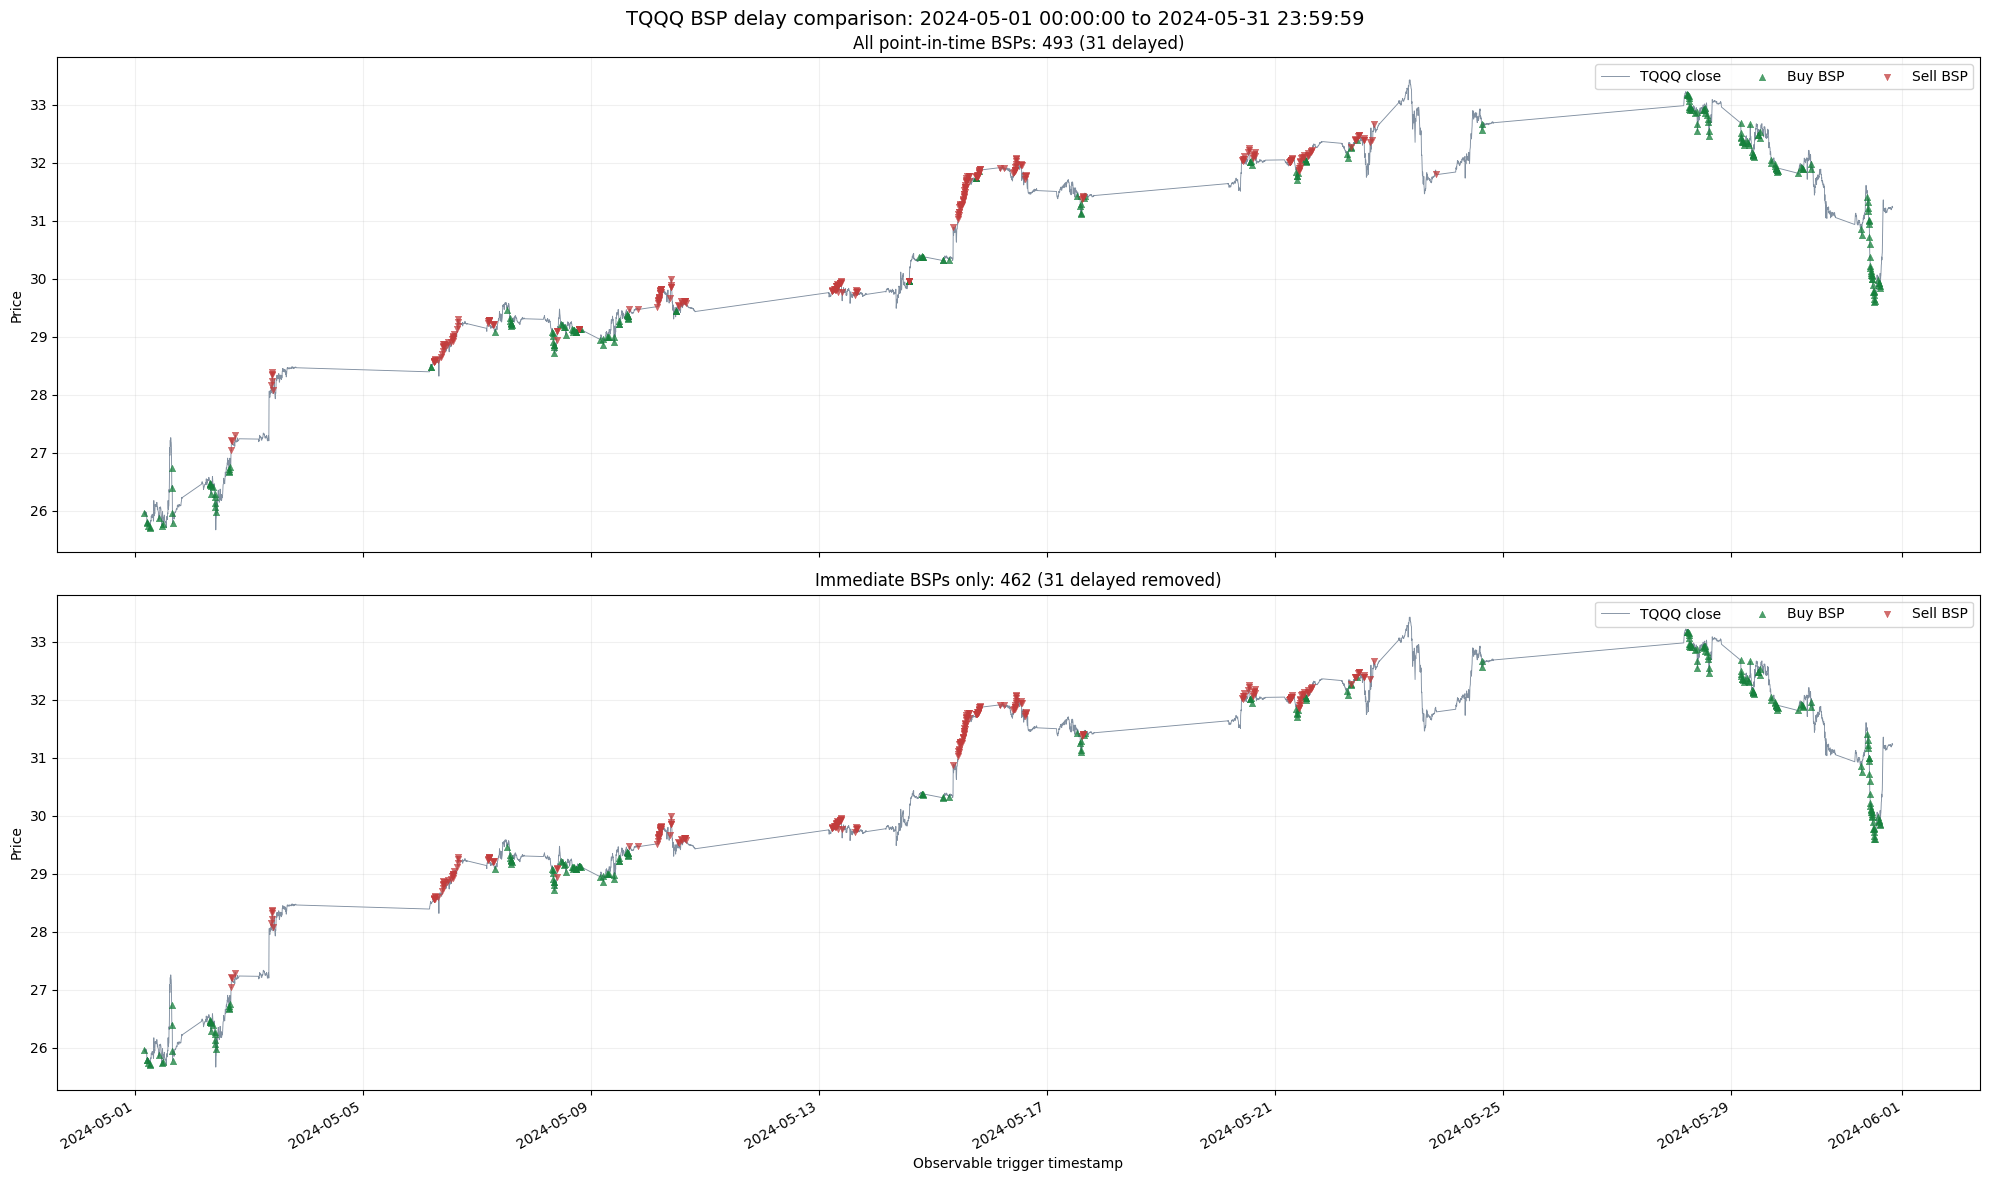

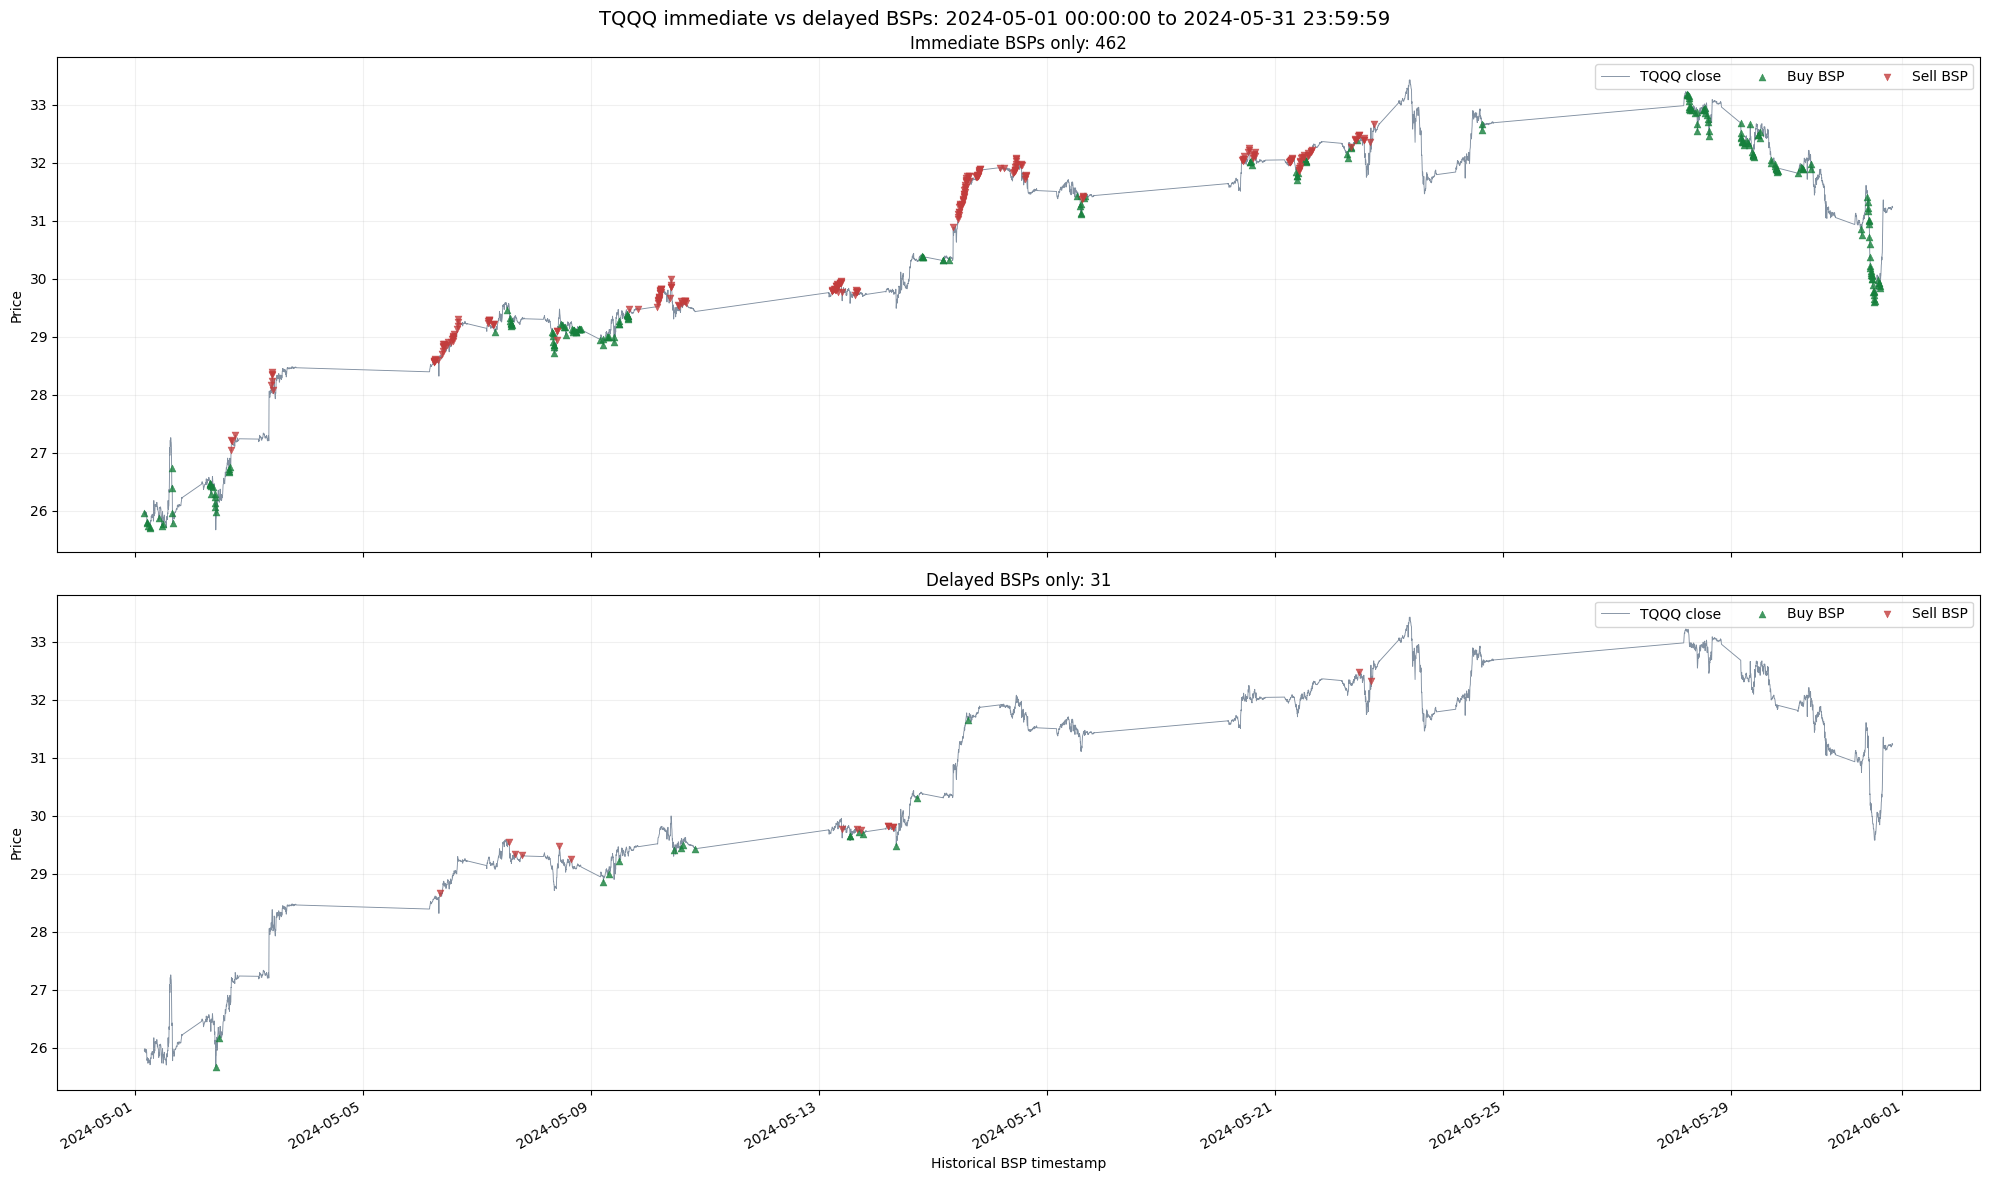

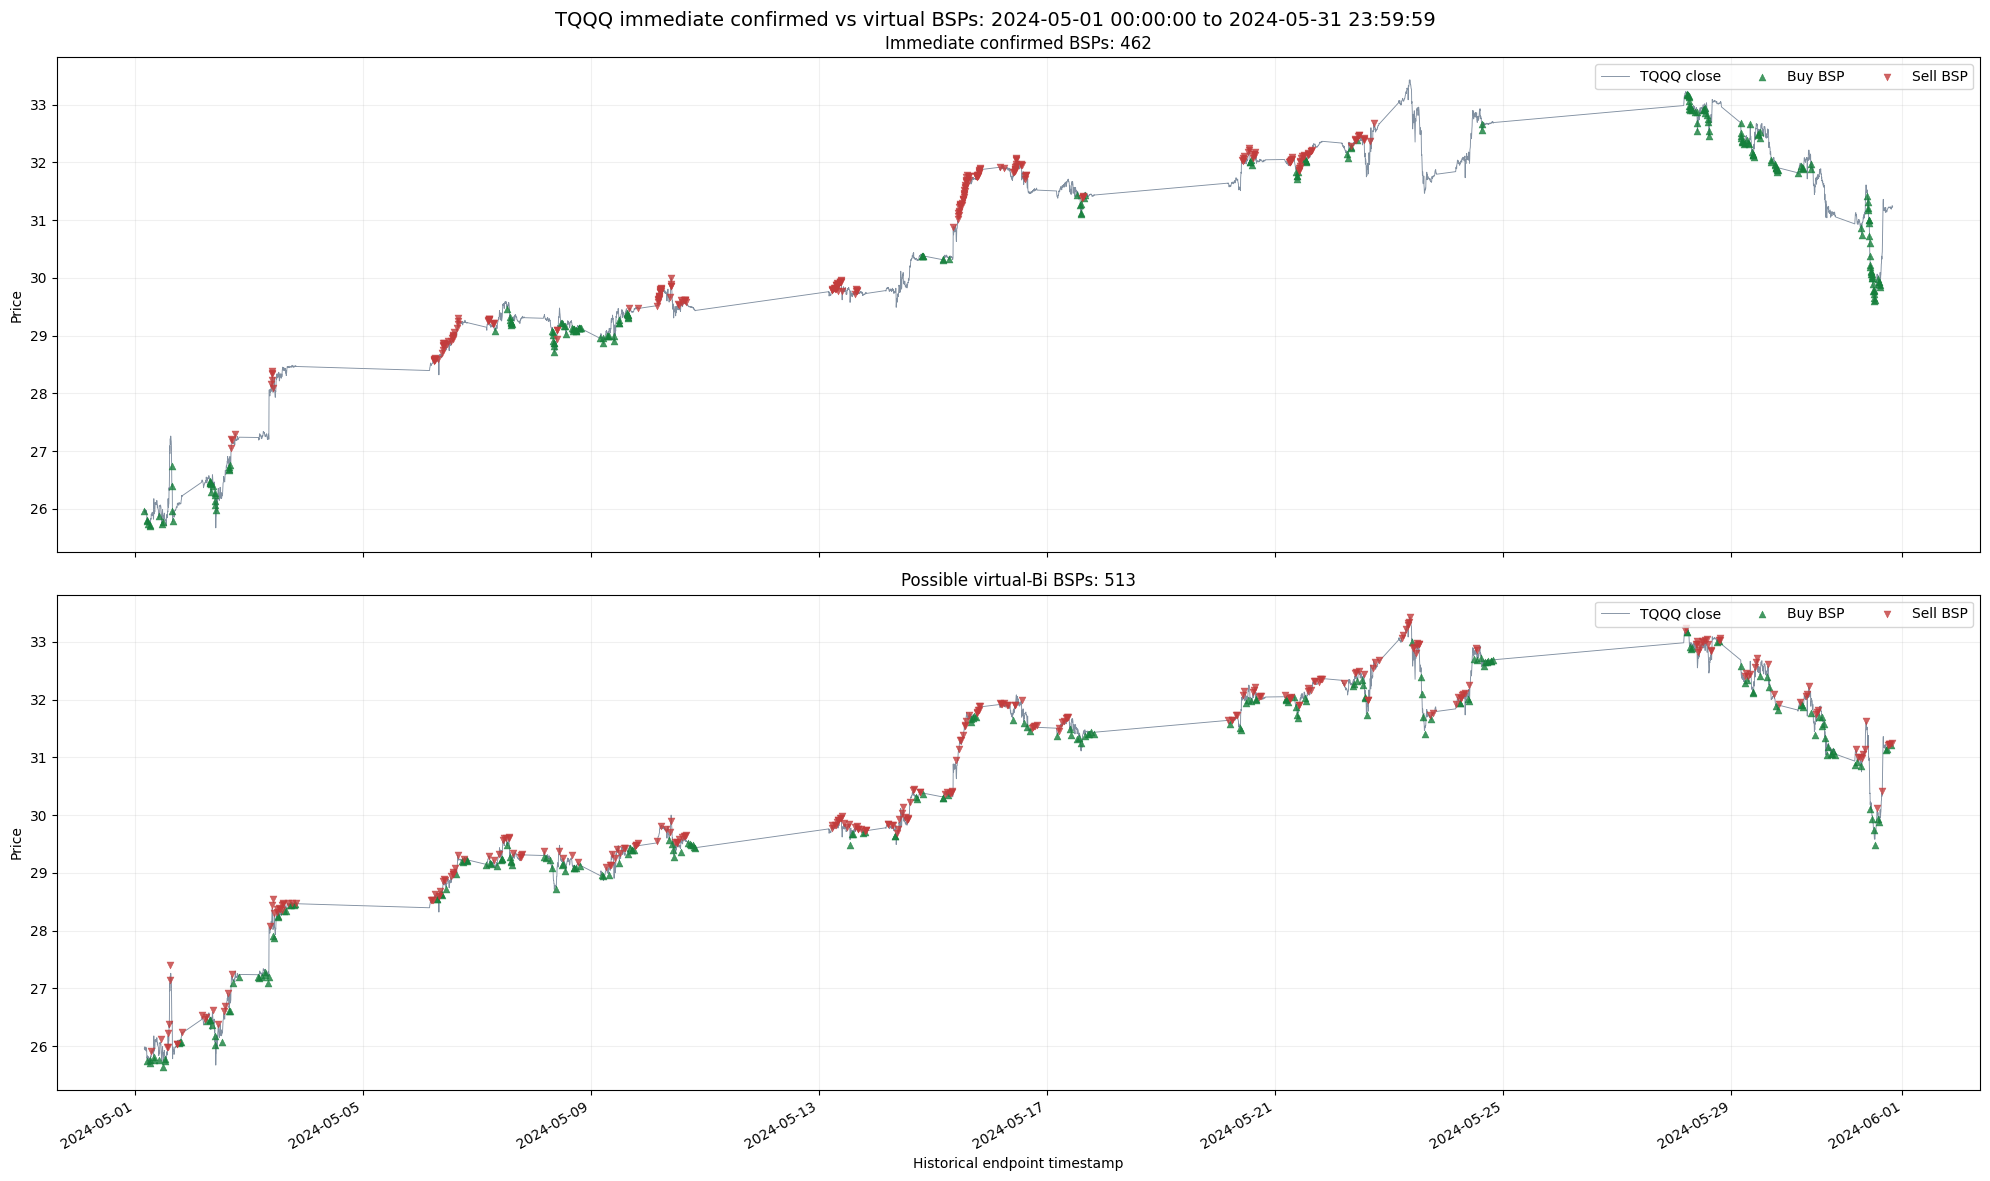

In [1]:
from dataclasses import replace
from pathlib import Path

from realistic_chan_simulation import (
    RealisticSimulationConfig,
    plot_bsp_delay_comparison_from_files,
    plot_delayed_bspoints_from_files,
    plot_immediate_vs_delayed_bspoints_from_files,
    plot_immediate_vs_virtual_bspoints_from_files,
)


config = RealisticSimulationConfig()

config = replace(
    config,
    data_path=Path("DataAPI/data/TQQQ_5M.csv"),
    bsp_workbook_path=Path(
        "outputs/bspoints_TQQQ_5m_2020-2026.xlsx"
    ),
    replay_mode="saved",

    chan=replace(
        config.chan,
        code="TQQQ",
        trigger_step=True,
        start="2020-01-01",
        end="2026-05-30",
        warmup_bars=500,
        max_klines=500,
    ),
)


# Select the period to display.
plot_start = "2024-05-01"
plot_end = "2024-05-31 23:59:59"


# ============================================================
# Plot 1
# Upper panel: all BSPs, including delayed BSPs.
# Lower panel: immediate BSPs only, with delayed BSPs removed.
# ============================================================

comparison_path = plot_bsp_delay_comparison_from_files(
    config,
    path="outputs/TQQQ_all_vs_without_delayed_2024_05.png",
    start=plot_start,
    end=plot_end,
    show=True,
)

#print(comparison_path)


# ============================================================
# Plot 2
# Only delayed BSPs:
# circles = historical BSP locations
# crosses = timestamps when the BSPs were discovered
# connecting lines = discovery delay
# ============================================================

delayed_only_path = plot_delayed_bspoints_from_files(
    config,
    path="outputs/TQQQ_only_delayed_2024_05.png",
    start=plot_start,
    end=plot_end,
    include_not_delayed=False,
    selection="all",
    annotate_largest=10,
)

comparison_path = plot_immediate_vs_delayed_bspoints_from_files(
    config,
    path="outputs/TQQQ_immediate_vs_delayed_2024_05.png",
    start=plot_start,
    end=plot_end,
    show=True,
)

comparison_path = plot_immediate_vs_virtual_bspoints_from_files(
    config,
    path="outputs/TQQQ_immediate_vs_virtual_2024_05.png",
    start=plot_start,
    end=plot_end,
    virtual_lookback_bars=5,
    show=True,
)

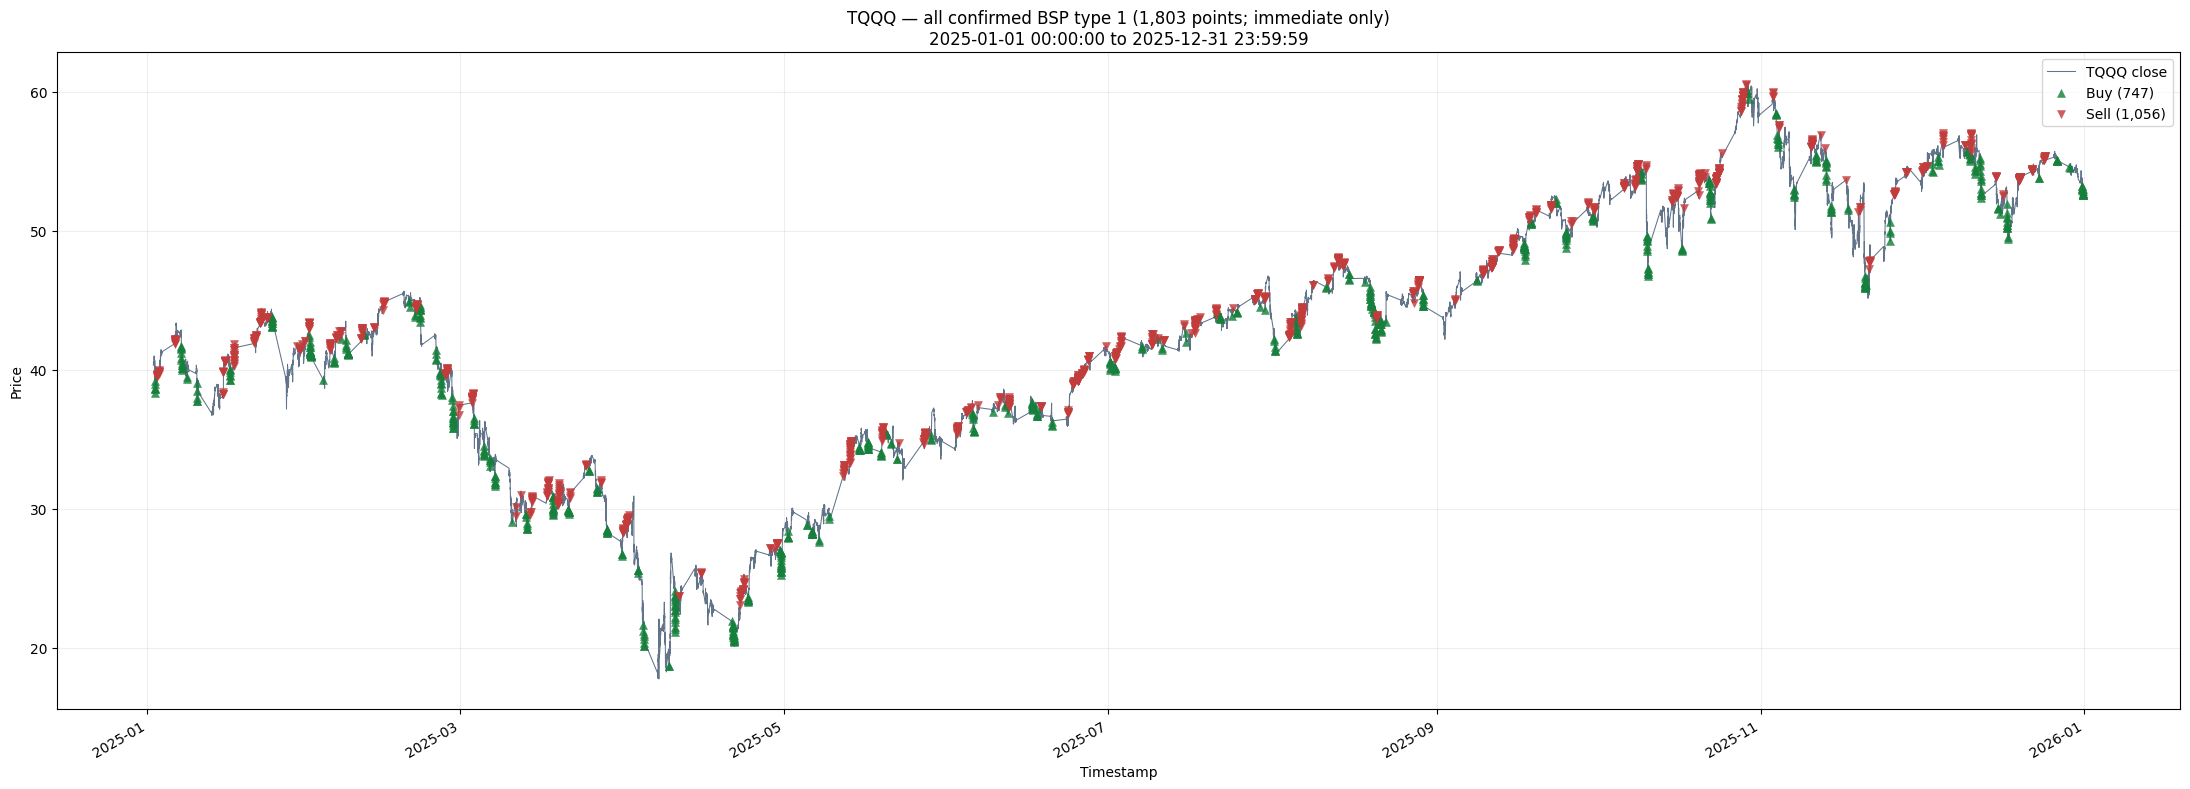

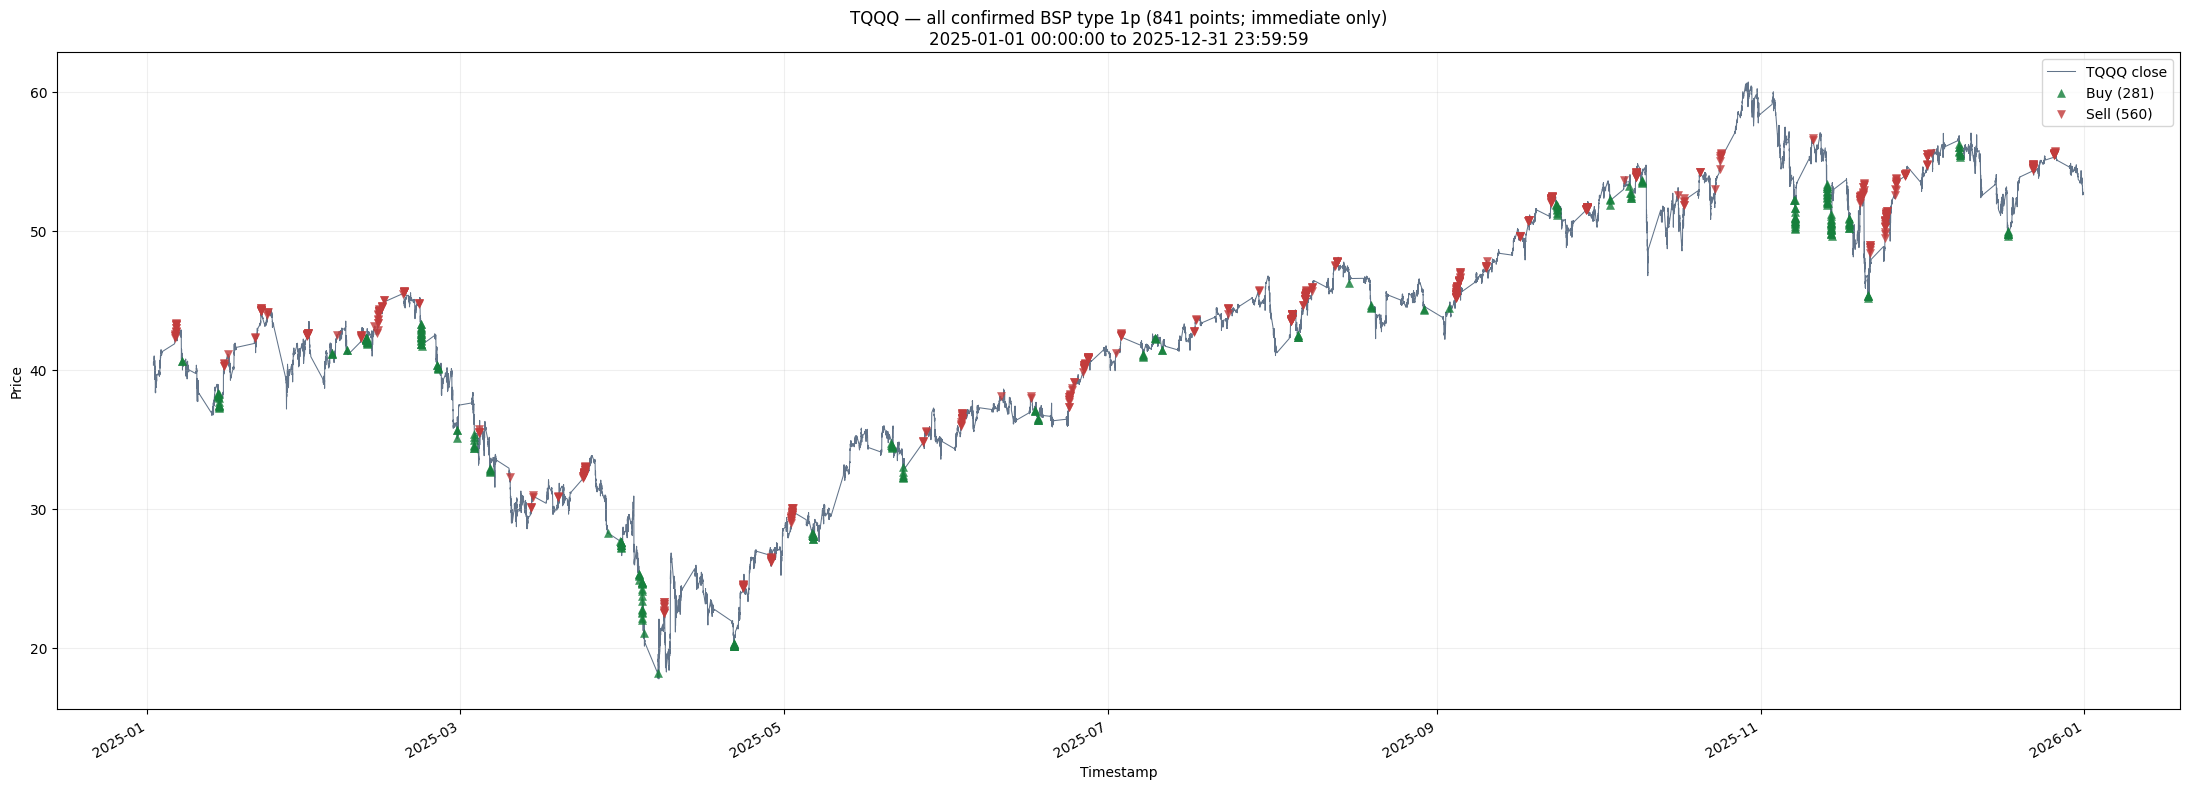

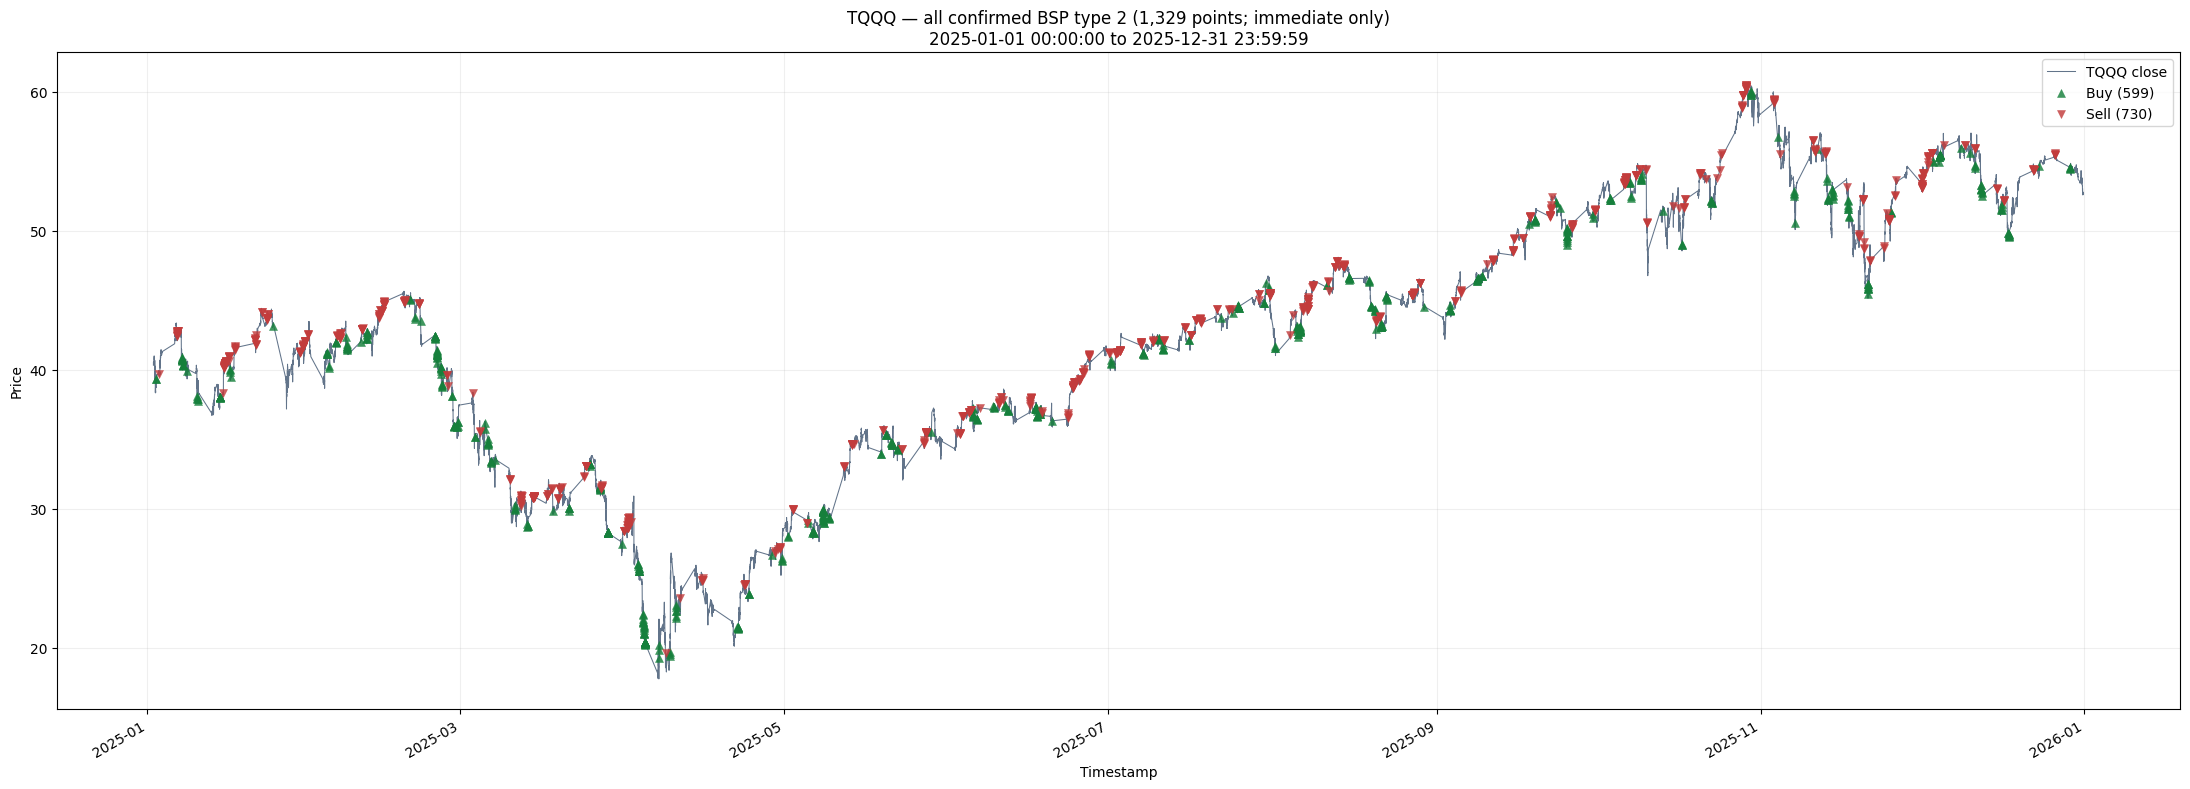

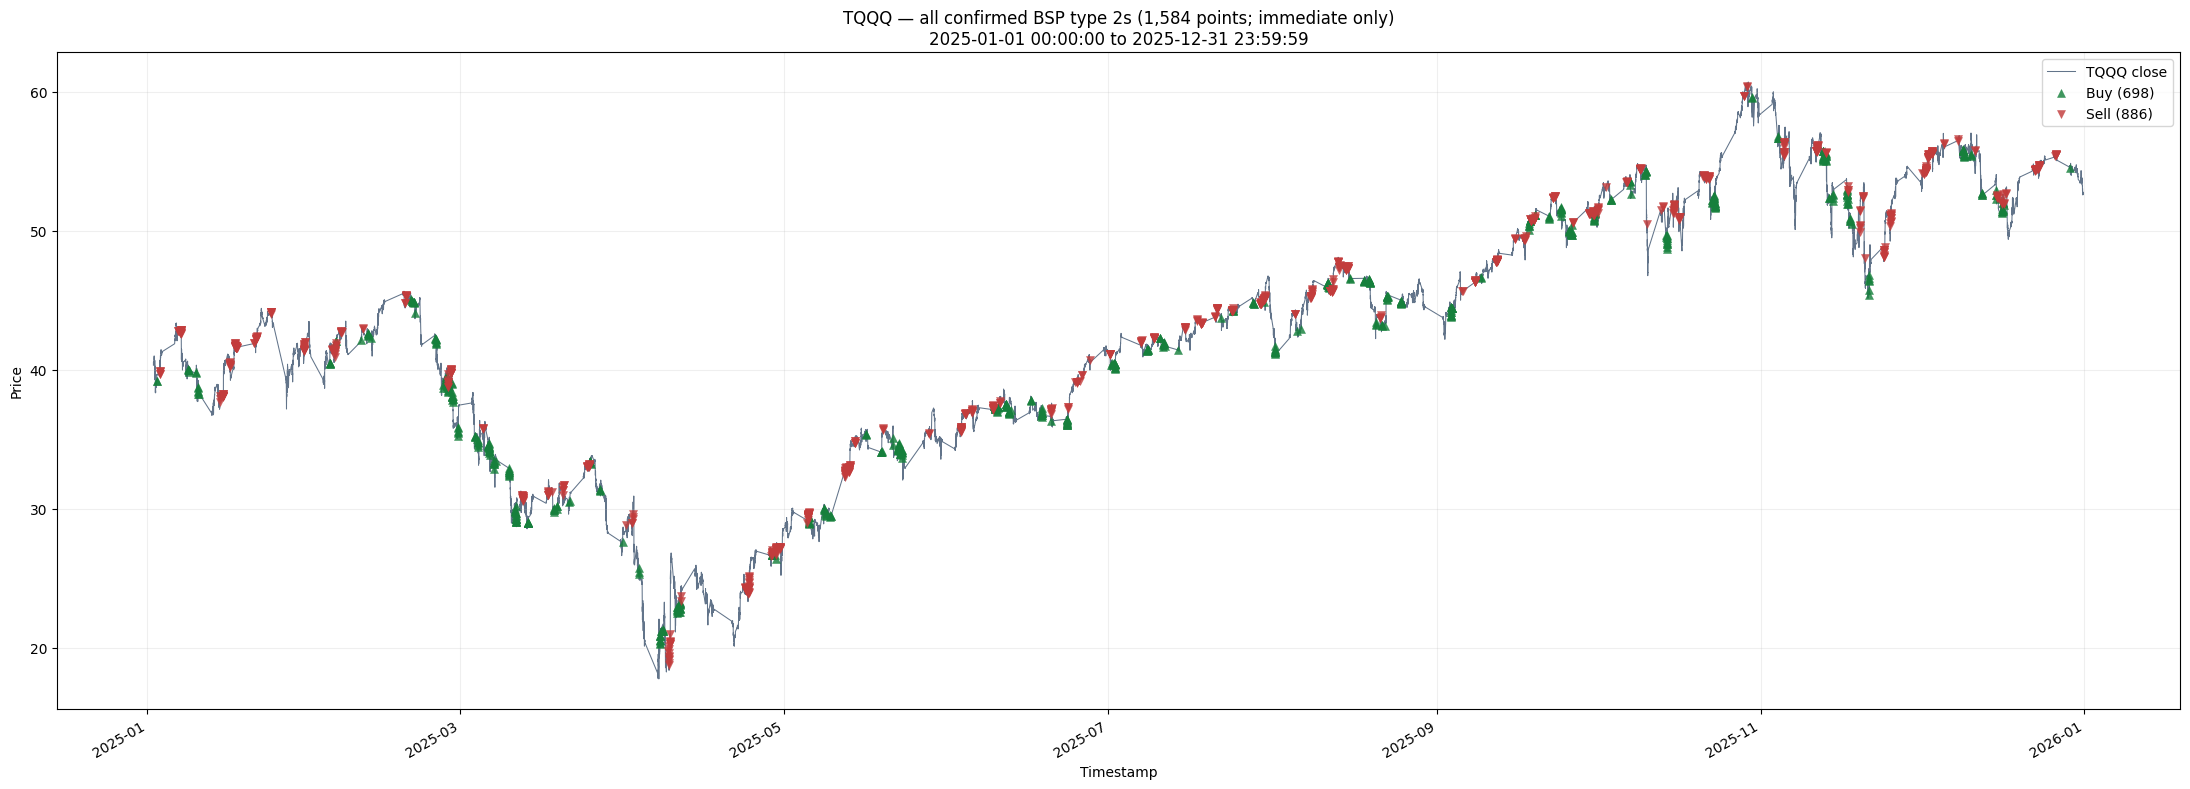

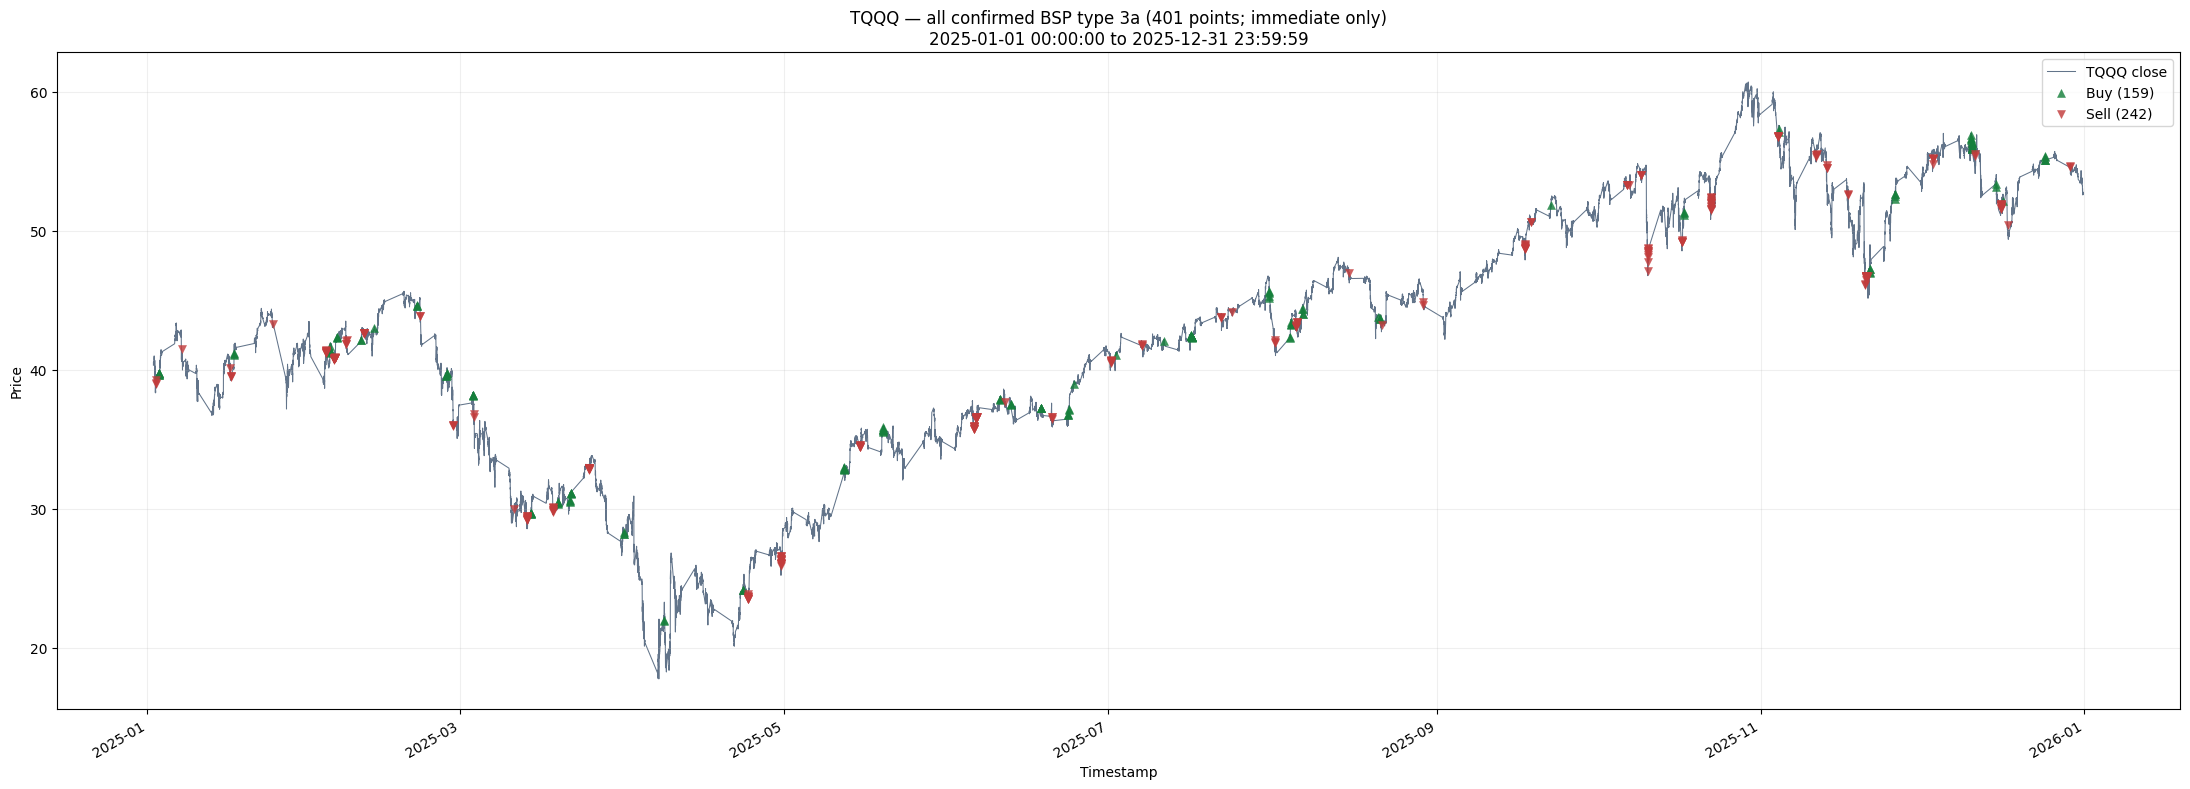

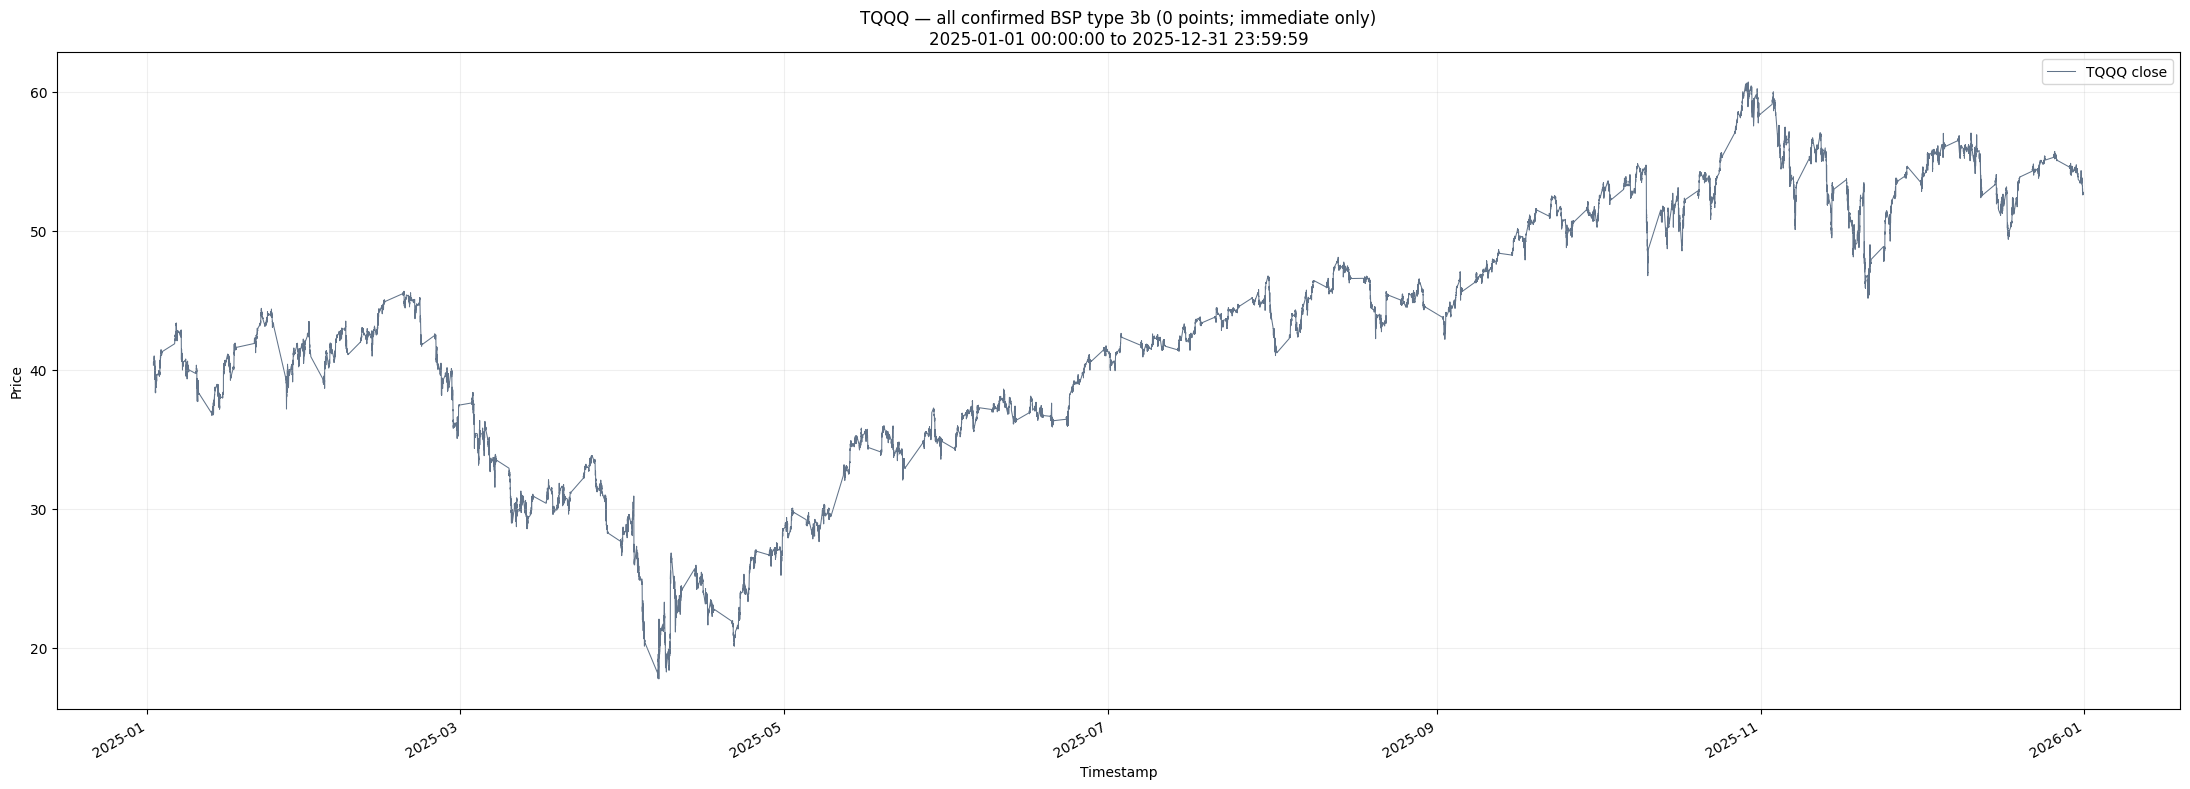

In [4]:
from realistic_chan_simulation import plot_bsp_type_examples_from_excel

type_paths = plot_bsp_type_examples_from_excel(
    config,

    bsp_workbook_path="outputs/bspoints_TQQQ_5m_2020-2026.xlsx",
    path="outputs/TQQQ_bsp_type_examples.png",

    start="2025-01-01",
    end="2025-12-31 23:59:59",

    example_types=(
        "1",
        "1p",
        "2",
        "2s",
        "3a",
        "3b",
    ),

    direction=None,

    # Exclude BSPs discovered after their historical timestamp
    include_delayed=False,

    all_points_by_type=True,
    show=True,
)

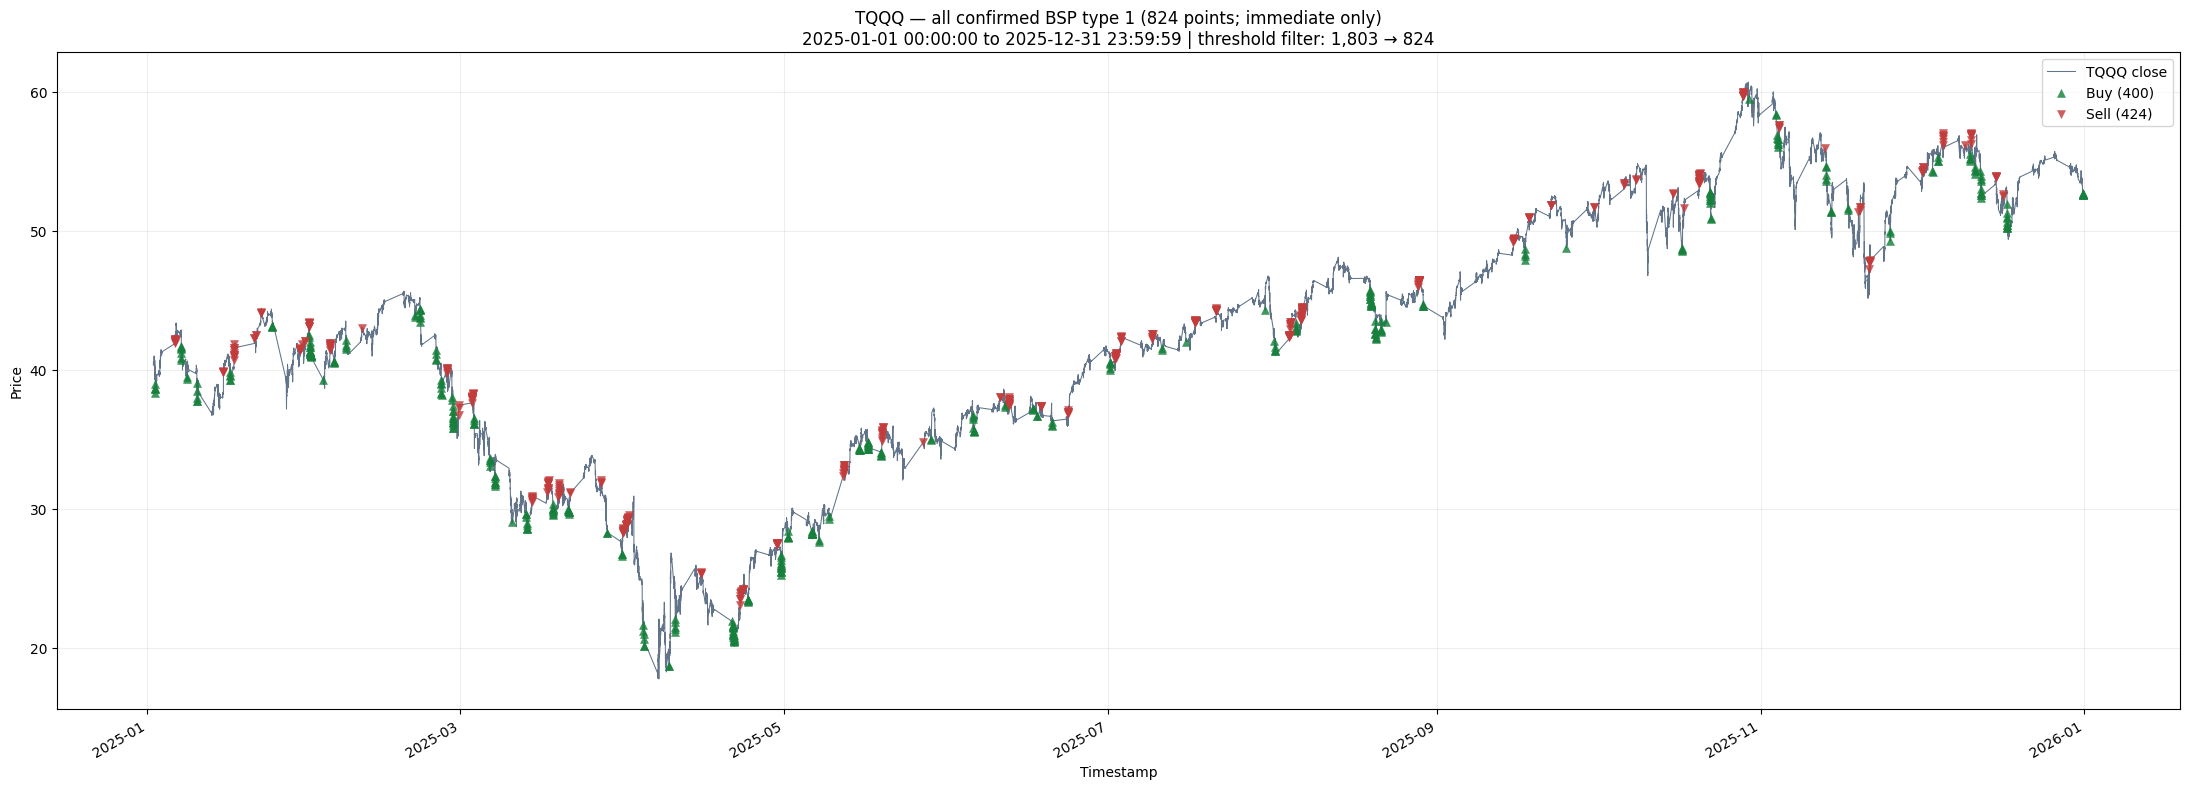

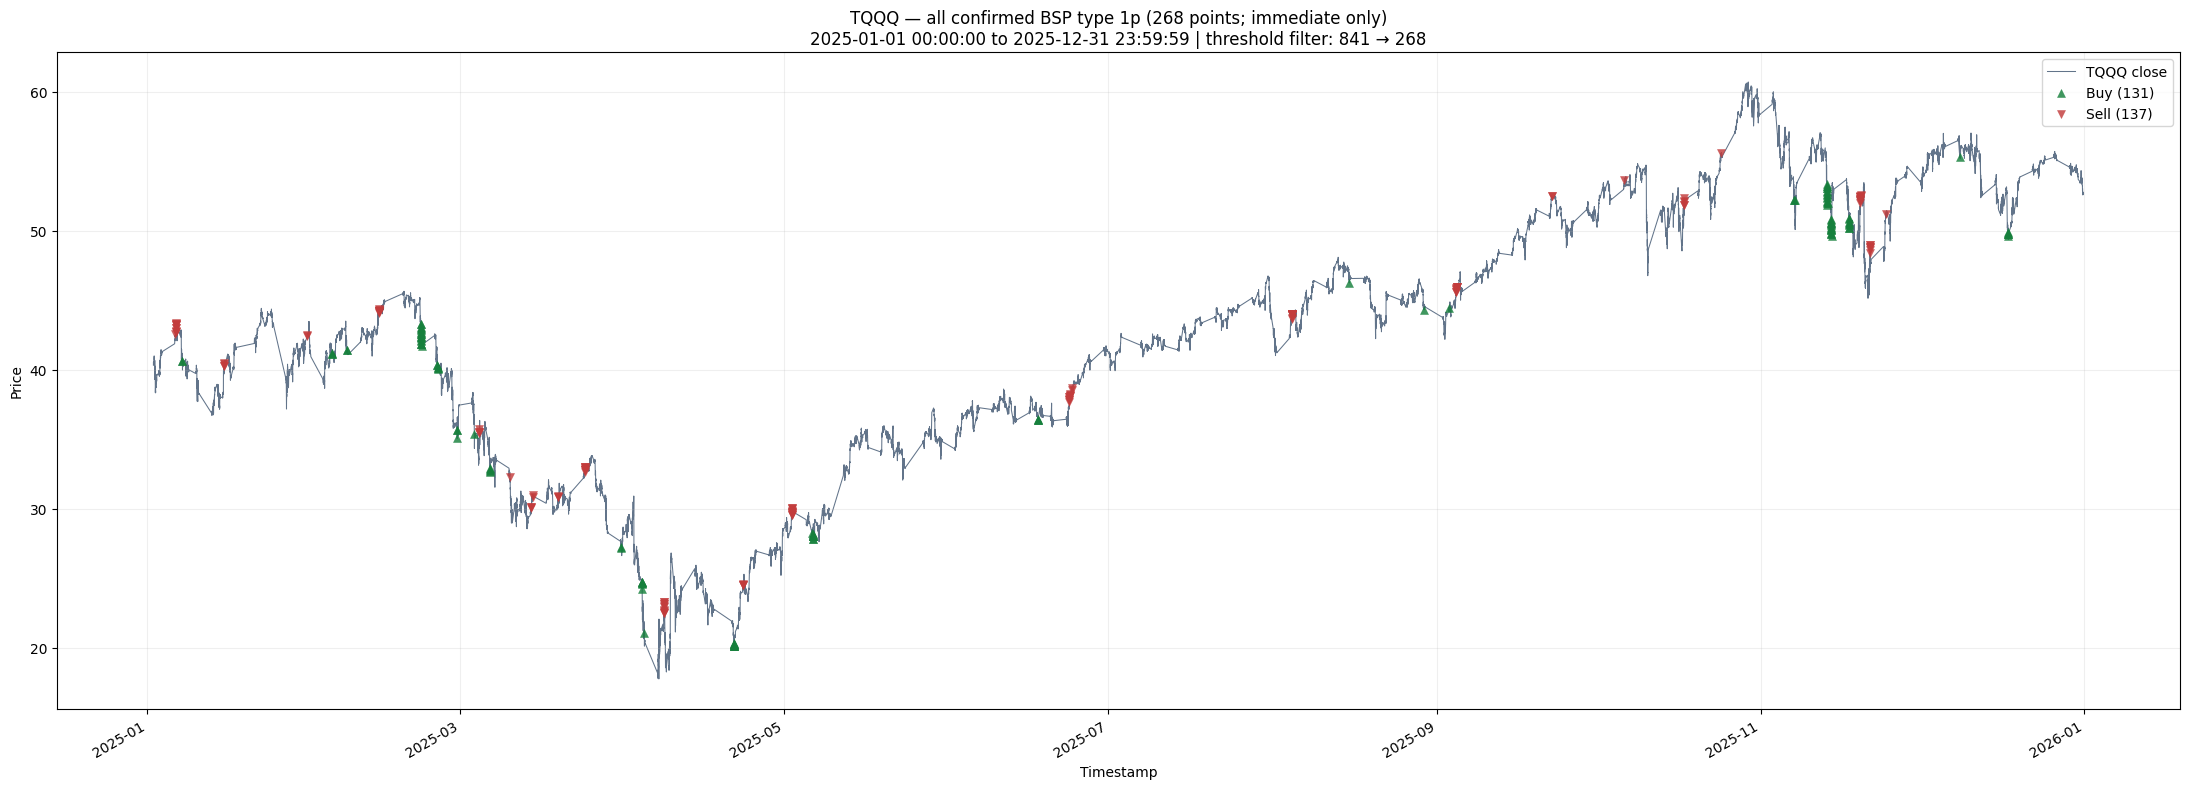

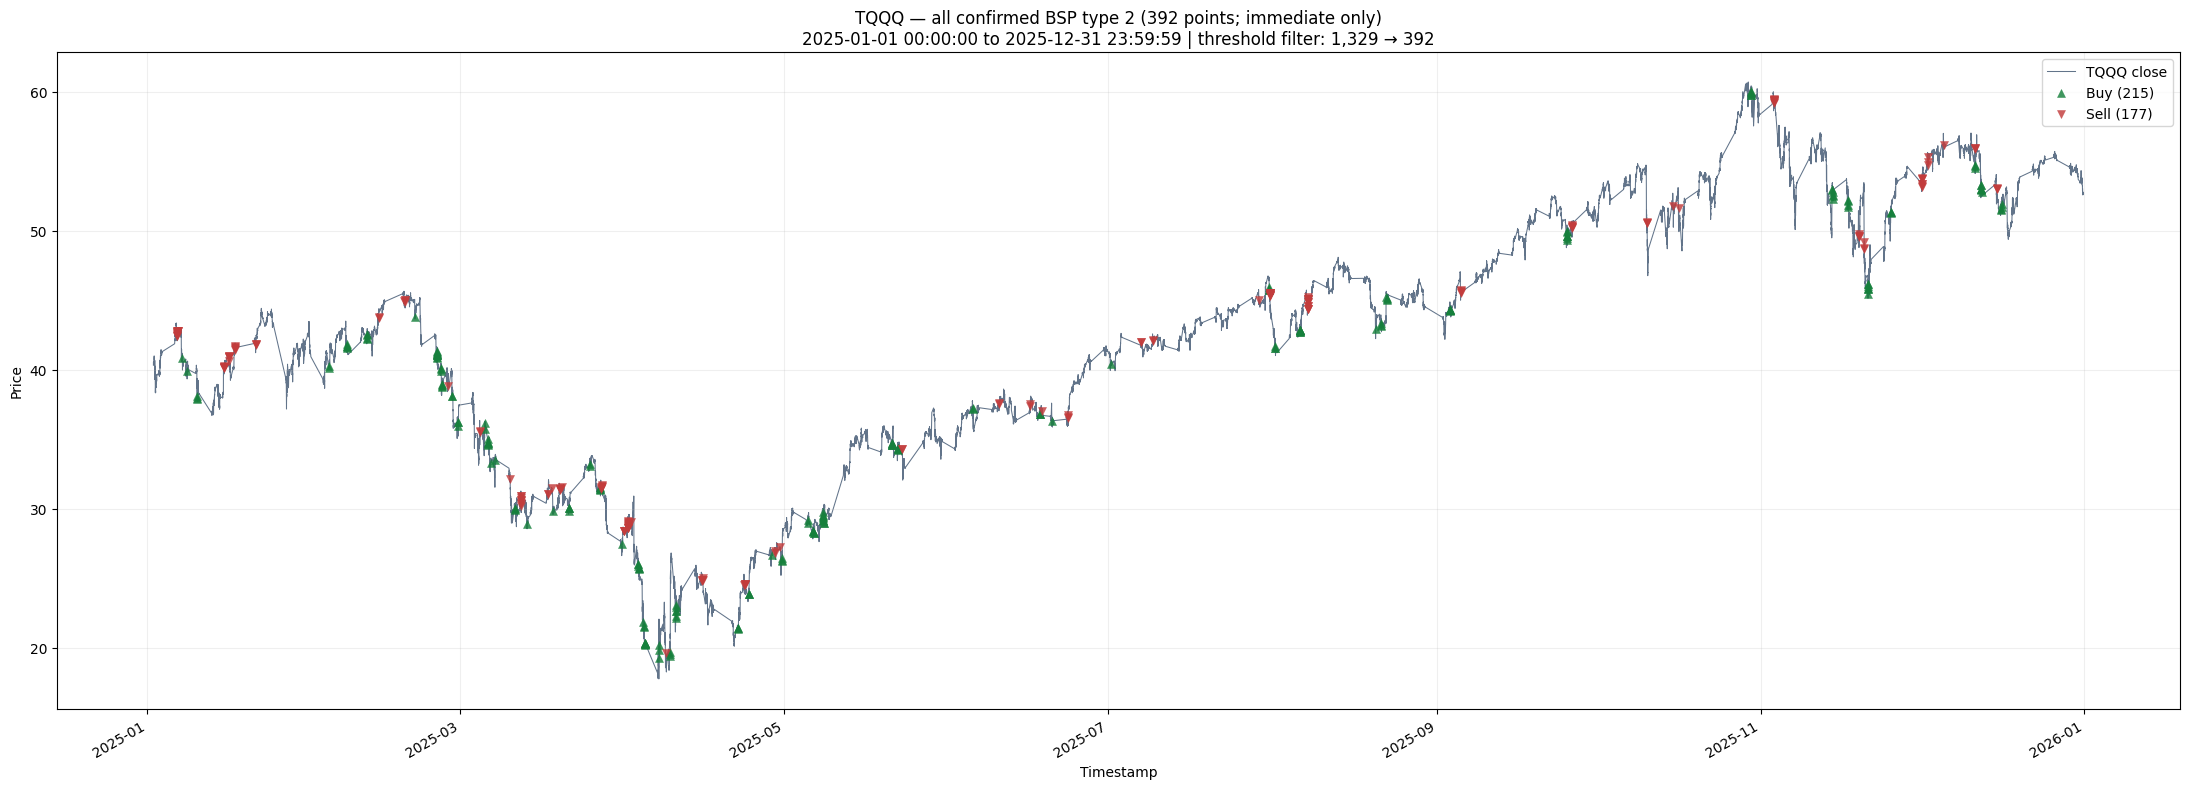

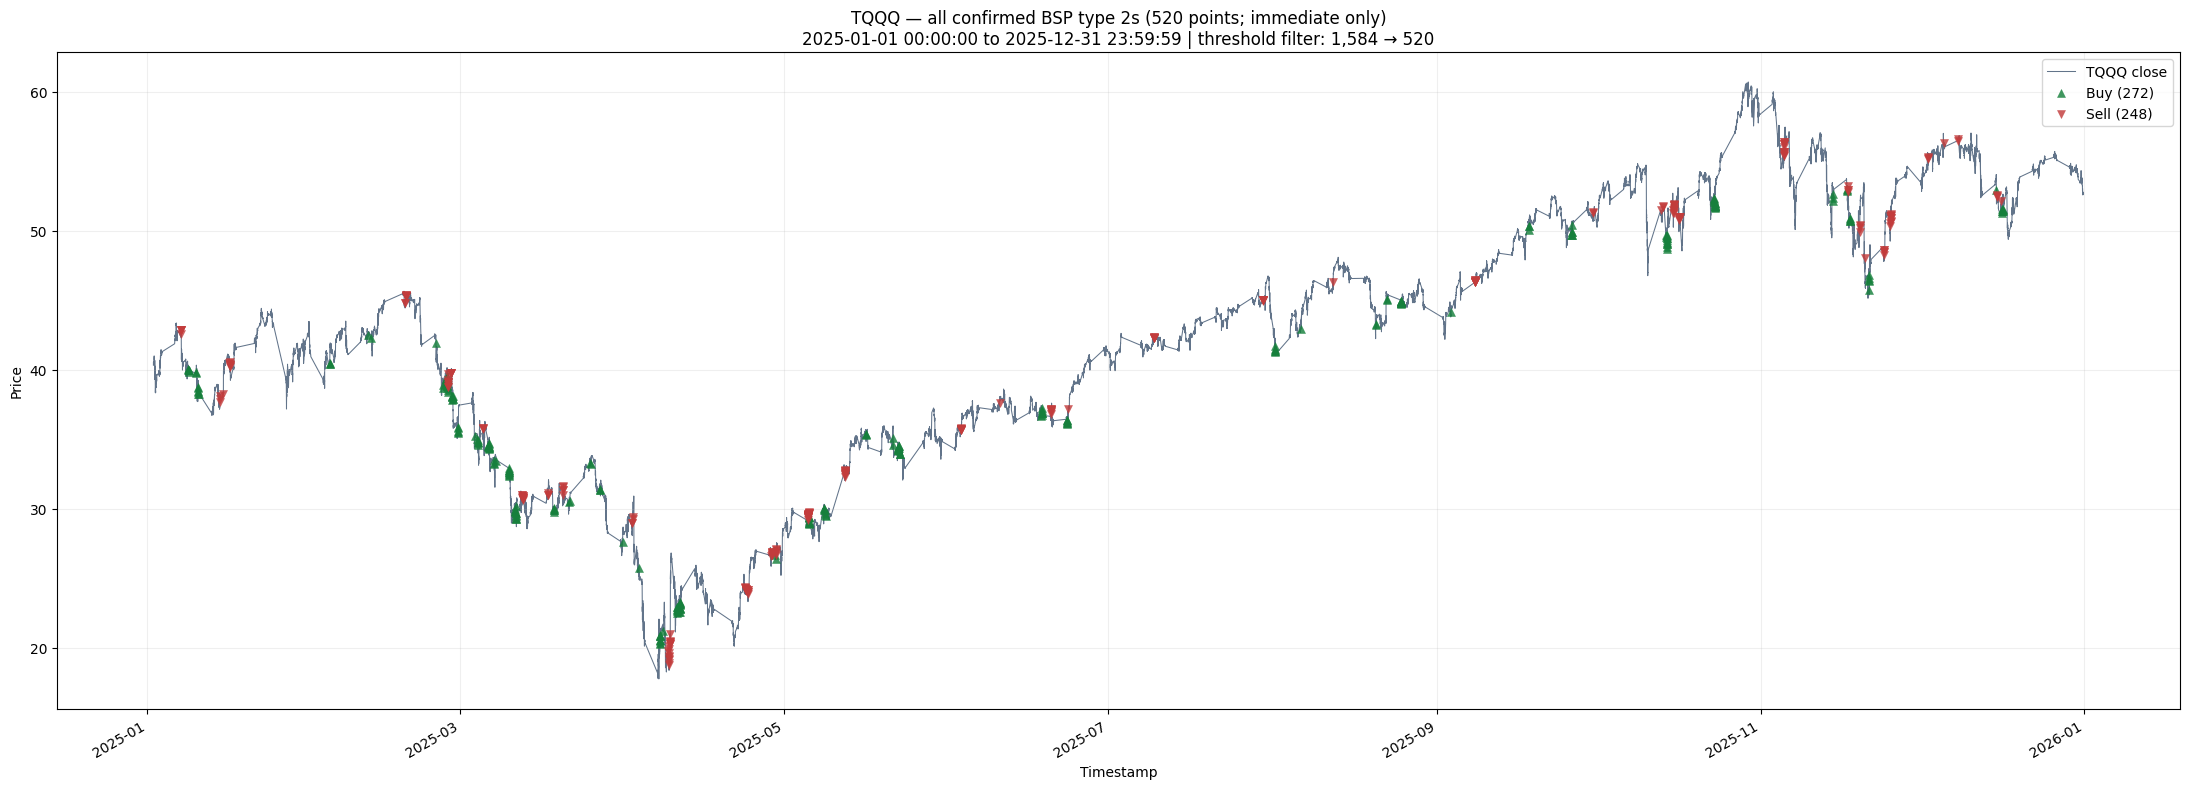

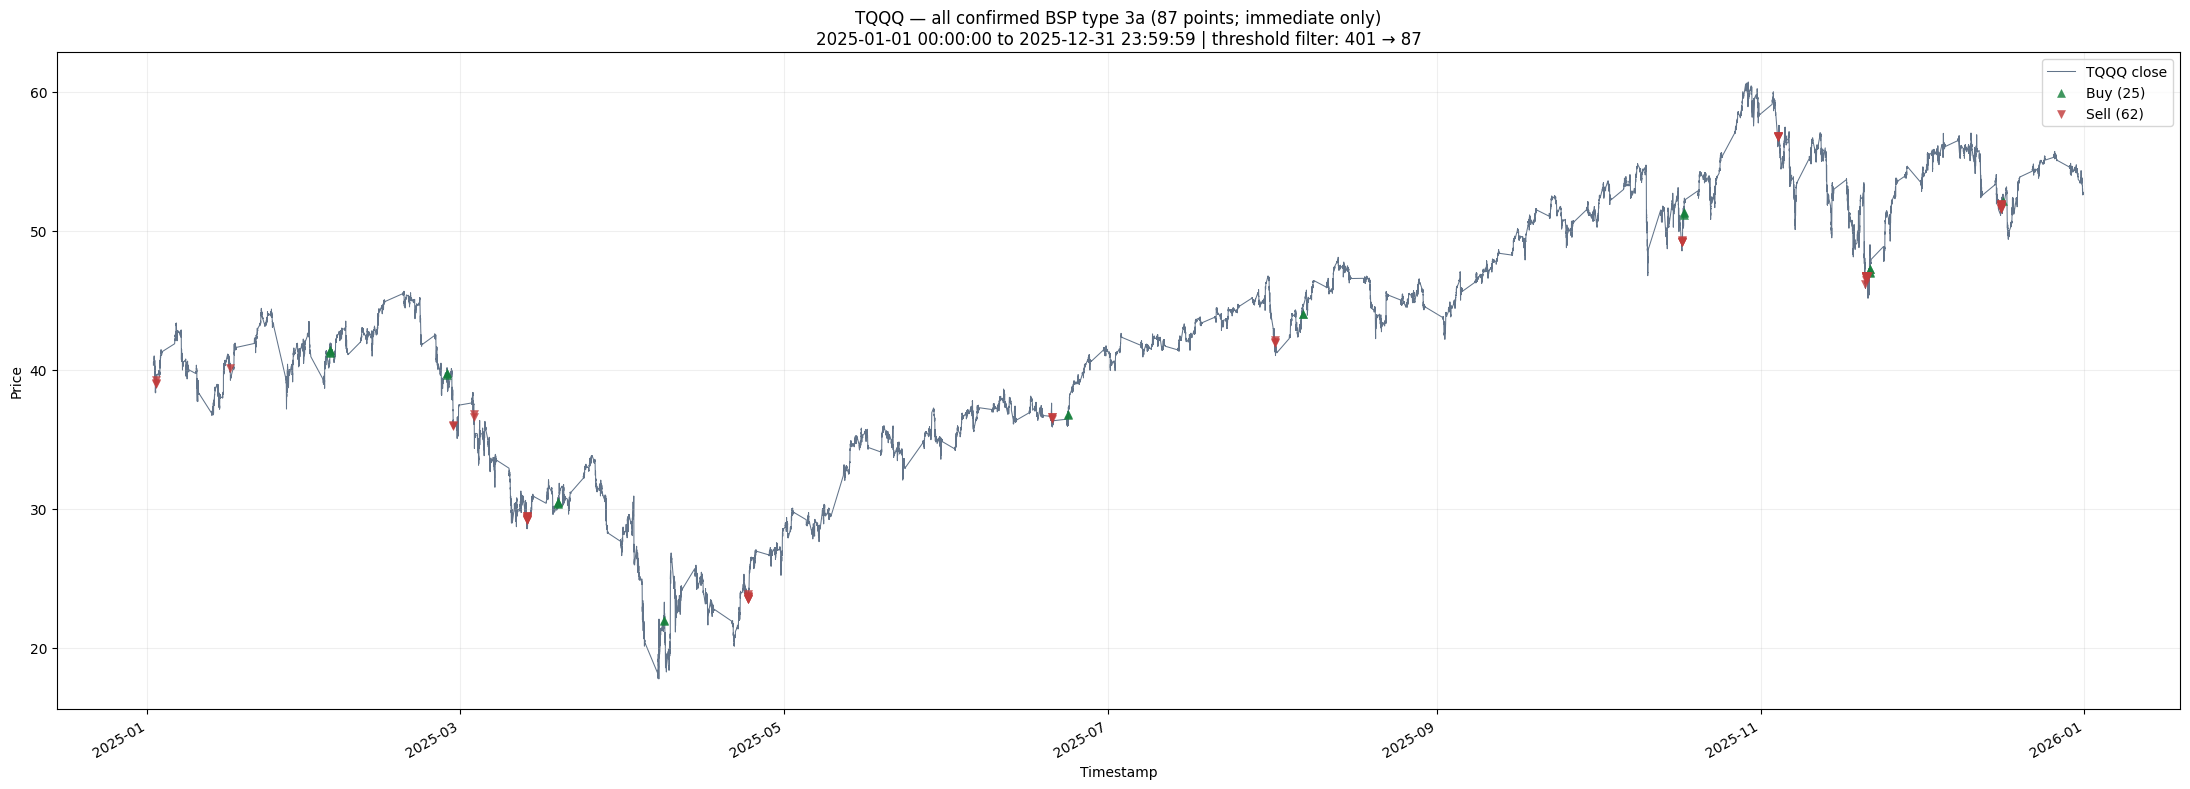

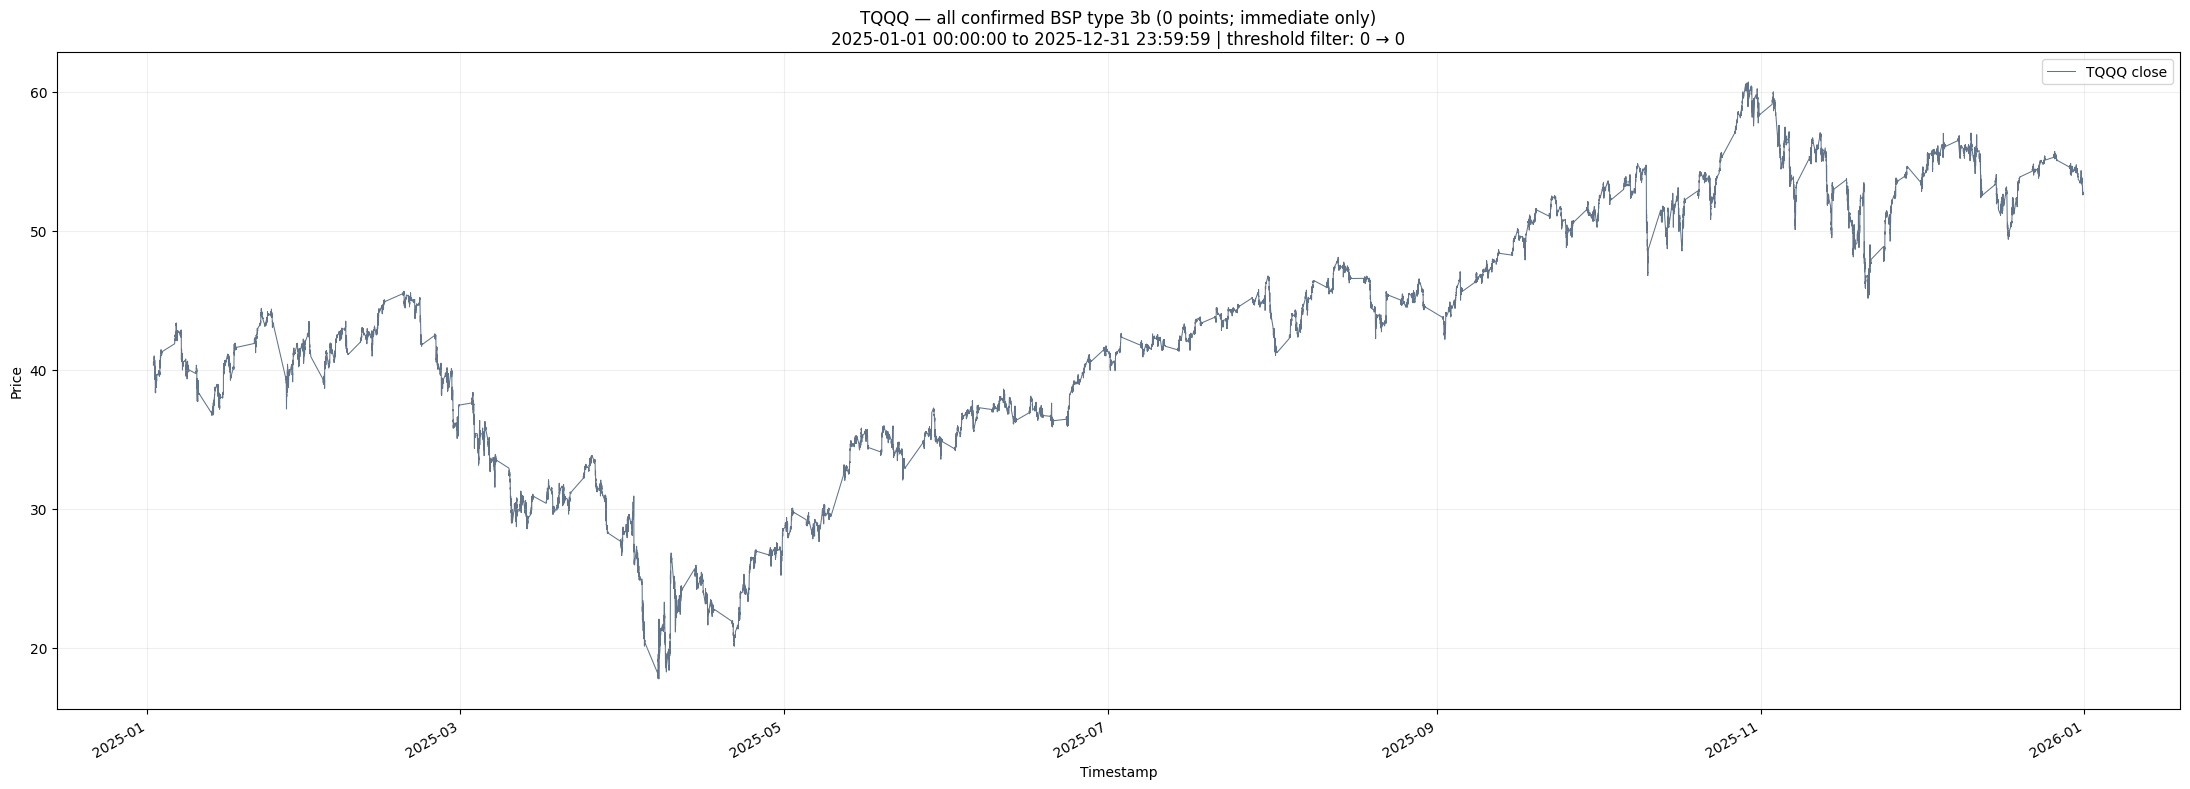

In [7]:
from realistic_chan_simulation import plot_bsp_type_examples_from_excel
type_paths = plot_bsp_type_examples_from_excel(
    config,
    bsp_workbook_path="outputs/bspoints_TQQQ_5m_2020-2026.xlsx",
    path="outputs/TQQQ_bsp_type_examples.png",

    start="2025-01-01",
    end="2025-12-31 23:59:59",

    example_types=("1", "1p", "2", "2s", "3a", "3b"),

    include_delayed=False,
    all_points_by_type=True,

    type_thresholds={
        "1": {
            "min_divergence_rate": 0.5,
            "min_bi_amp_rate": 0.02,
            "min_bi_klu_cnt": 5,
            "min_zs_cnt": 1,
        },

        "1p": {
            "max_divergence_rate": 0.8,
            "min_bi_amp_rate": 0.015,
            "min_bi_klu_cnt": 5,
        },

        "2": {
            "max_retrace_rate": 0.8,
            "min_break_bi_amp_rate": 0.02,
            "min_bi_amp_rate": 0.01,
            "min_bi_klu_cnt": 5,
        },

        "2s": {
            "max_retrace_rate": 0.8,
            "max_level": 3,
            "min_break_bi_amp_rate": 0.02,
            "min_bi_amp_rate": 0.01,
        },

        "3a": {
            "min_zs_height": 0.01,
            "min_bi_amp_rate": 0.01,
            "min_bi_klu_cnt": 5,
        },

        "3b": {
            "min_zs_height": 0.01,
            "min_bi_amp_rate": 0.01,
            "min_bi_klu_cnt": 5,
        },
    },

    show=True,
)

In [ ]:
import importlib
import realistic_chan_simulation

importlib.reload(realistic_chan_simulation)

from realistic_chan_simulation import (
    interactive_bsp_type_explorer_from_excel,
)

dashboard = interactive_bsp_type_explorer_from_excel(
    config,
    bsp_workbook_path="outputs/bspoints_TQQQ_5m_2020-2026.xlsx",

    start="2025-01-01",
    end="2025-12-31 23:59:59",

    example_types=(
        "1",
        "1p",
        "2",
        "2s",
        "3a",
        "3b",
    ),

    max_background_points=75_000,
)

In [2]:
from dataclasses import replace
from pathlib import Path

from realistic_chan_simulation import (
    RealisticSimulationConfig,
    run_realistic_simulation,
    print_simulation_summary,
)

config = RealisticSimulationConfig()

config = replace(
    config,
    data_path=Path("DataAPI/data/TQQQ_5M.csv"),
    bsp_workbook_path=Path(
        "outputs/bspoints_TQQQ_5m_2020-2026.xlsx"
    ),
    replay_mode="regenerate",

    chan=replace(
        config.chan,
        code="TQQQ",
        trigger_step=True,
        start="2020-01-01",
        end="2026-05-30",
        warmup_bars=500,
        max_klines=500,
    ),

    risk=replace(
        config.risk,
        stop_loss_pct=0.10,
        take_profit_pct=0.15,
        trailing_stop_pct=0.15,
        max_holding_bars=78 * 10,
    ),

    backtest=replace(
        config.backtest,
        initial_capital=100_000,
        fee_pct=0.0,
        slippage_pct=0.0,
    ),
)
from realistic_chan_simulation import save_virtual_bsp_candidates_to_excel

virtual_bsp_path = save_virtual_bsp_candidates_to_excel(
    config,
    path="outputs/TQQQ_virtual_bsp_candidates.xlsx",
    start="2020-01-01",
    end="2026-05-30 23:59:59",
    virtual_lookback_bars=5,
)

print(virtual_bsp_path)

C:\Users\TonyTang\Documents\chan.py\outputs\TQQQ_virtual_bsp_candidates.xlsx


Price rows: 306,208
Chan feed rows (including warmup): 0
Point-in-time BSP events: 33,132
Simulation period: 2020-01-02 04:00:00 to 2026-05-29 19:55:00

Strategy metrics:
final_equity: 242407.88822598662
total_return: 1.4240788822598662
max_drawdown: -0.43545022626421315
sharpe: 0.39228885873460784
closed_trades: 804
win_rate: 0.5509950248756219
profit_factor: 1.1504488421764618


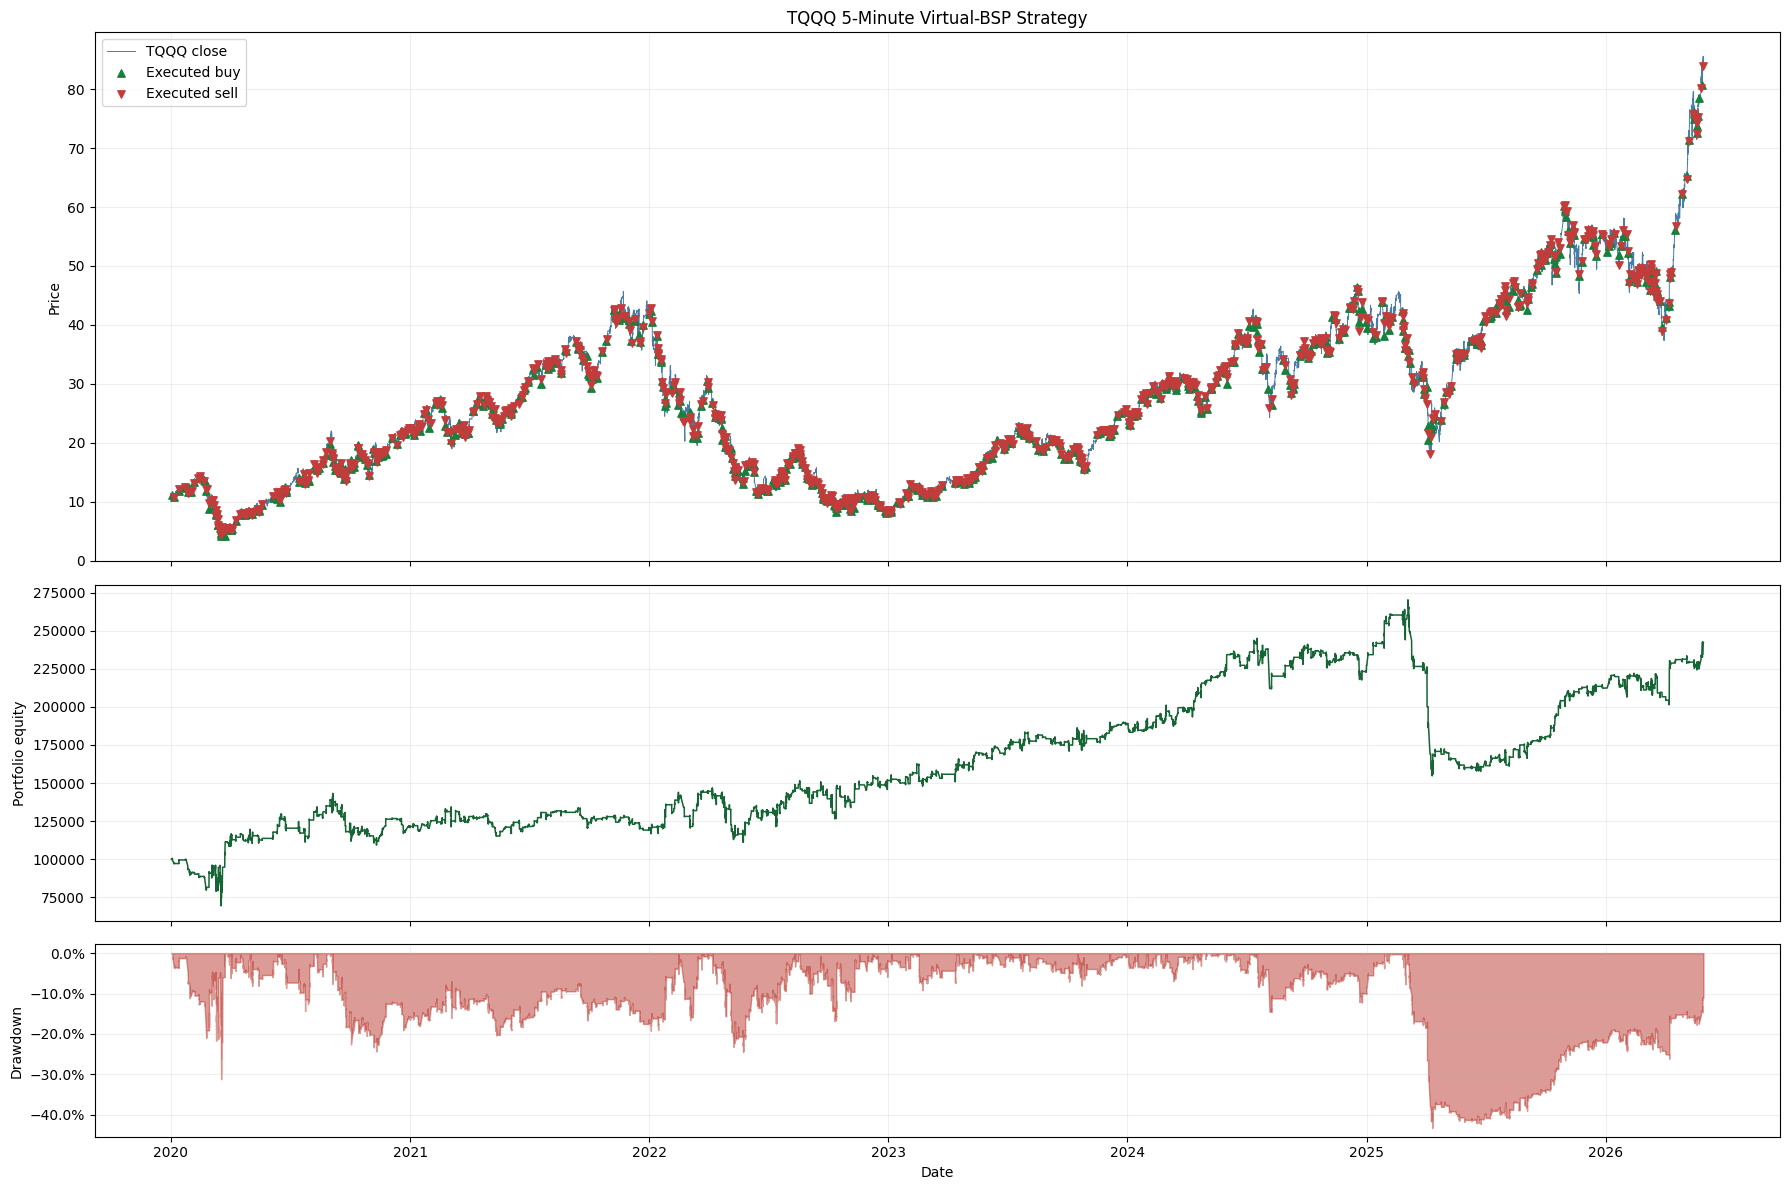

C:\Users\TonyTang\Documents\chan.py\outputs\TQQQ_virtual_bsp_strategy_result.png


In [13]:
from dataclasses import replace
from pathlib import Path

from realistic_chan_simulation import (
    RealisticSimulationConfig,
    run_virtual_bsp_simulation_from_excel,
    print_simulation_summary,
    plot_simulation_result,
)


# ============================================================
# EDITABLE VIRTUAL-BSP ENTRY SETTINGS
# ============================================================

buy_lookback_bars_by_segment = {
    "up": 10,
    "down": 10,
}

required_buy_signals_by_segment = {
    "up": {
        "virtual_bi": 2,
    },
    "down": {
        "virtual_bi": 5,
    },
}


# ============================================================
# EDITABLE VIRTUAL-BSP EXIT SETTINGS
# ============================================================

# These depend on the segment in which the trade was opened.
sell_lookback_bars_by_entry_segment = {
    "up": 10,
    "down": 10,
}

required_sell_signals_by_entry_segment = {
    "up": {
        "virtual_bi": 5,
    },
    "down": {
        "virtual_bi": 2,
    },
}


# ============================================================
# BUILD CONFIGURATION
# ============================================================

config = RealisticSimulationConfig()

config = replace(
    config,

    data_path=Path(
        "DataAPI/data/TQQQ_5M.csv"
    ),

    # This is now the virtual-BSP workbook.
    bsp_workbook_path=Path(
        "outputs/TQQQ_virtual_bsp_candidates.xlsx"
    ),

    replay_mode="saved",

    chan=replace(
        config.chan,
        code="TQQQ",
        start="2020-01-01",
        end="2026-05-30 23:59:59",
        warmup_bars=500,
        max_klines=500,
    ),

    strategy=replace(
        config.strategy,

        # Allow virtual candidates from both segment directions.
        entry_segment_directions=frozenset({
            "up",
            "down",
        }),

        # Virtual dataset contains only this BSP type.
        entry_bsp_types=frozenset({
            "virtual_bi",
        }),

        sell_bsp_types=frozenset({
            "virtual_bi",
        }),

        # Buy requirements
        buy_lookback_bars_by_segment=(
            buy_lookback_bars_by_segment
        ),

        required_buy_signals_by_segment=(
            required_buy_signals_by_segment
        ),

        # Sell requirements based on the entry segment
        sell_lookback_bars_by_entry_segment=(
            sell_lookback_bars_by_entry_segment
        ),

        required_sell_signals_by_entry_segment=(
            required_sell_signals_by_entry_segment
        ),

        # Virtual structures may still be unconfirmed.
        allow_unconfirmed_entry=True,

        # Use virtual Sell requirements instead of automatically
        # exiting whenever the current segment becomes down.
        exit_on_down_segment=False,
    ),

    risk=replace(
        config.risk,
        stop_loss_pct=0.10,
        take_profit_pct=0.15,
        trailing_stop_pct=0.15,
        max_holding_bars=78 * 10,
    ),

    backtest=replace(
        config.backtest,
        initial_capital=100_000,
        fee_pct=0.0,
        slippage_pct=0.0,
    ),
)


# ============================================================
# RUN DIRECTLY FROM THE SAVED EXCEL
# ============================================================

output = run_virtual_bsp_simulation_from_excel(config)

print_simulation_summary(output)


# ============================================================
# PLOT STRATEGY RESULTS
# ============================================================

plot_path = plot_simulation_result(
    output,
    path=Path(
        "outputs/TQQQ_virtual_bsp_strategy_result.png"
    ),
    title="TQQQ 5-Minute Virtual-BSP Strategy",
    show=True,
)

print(plot_path)

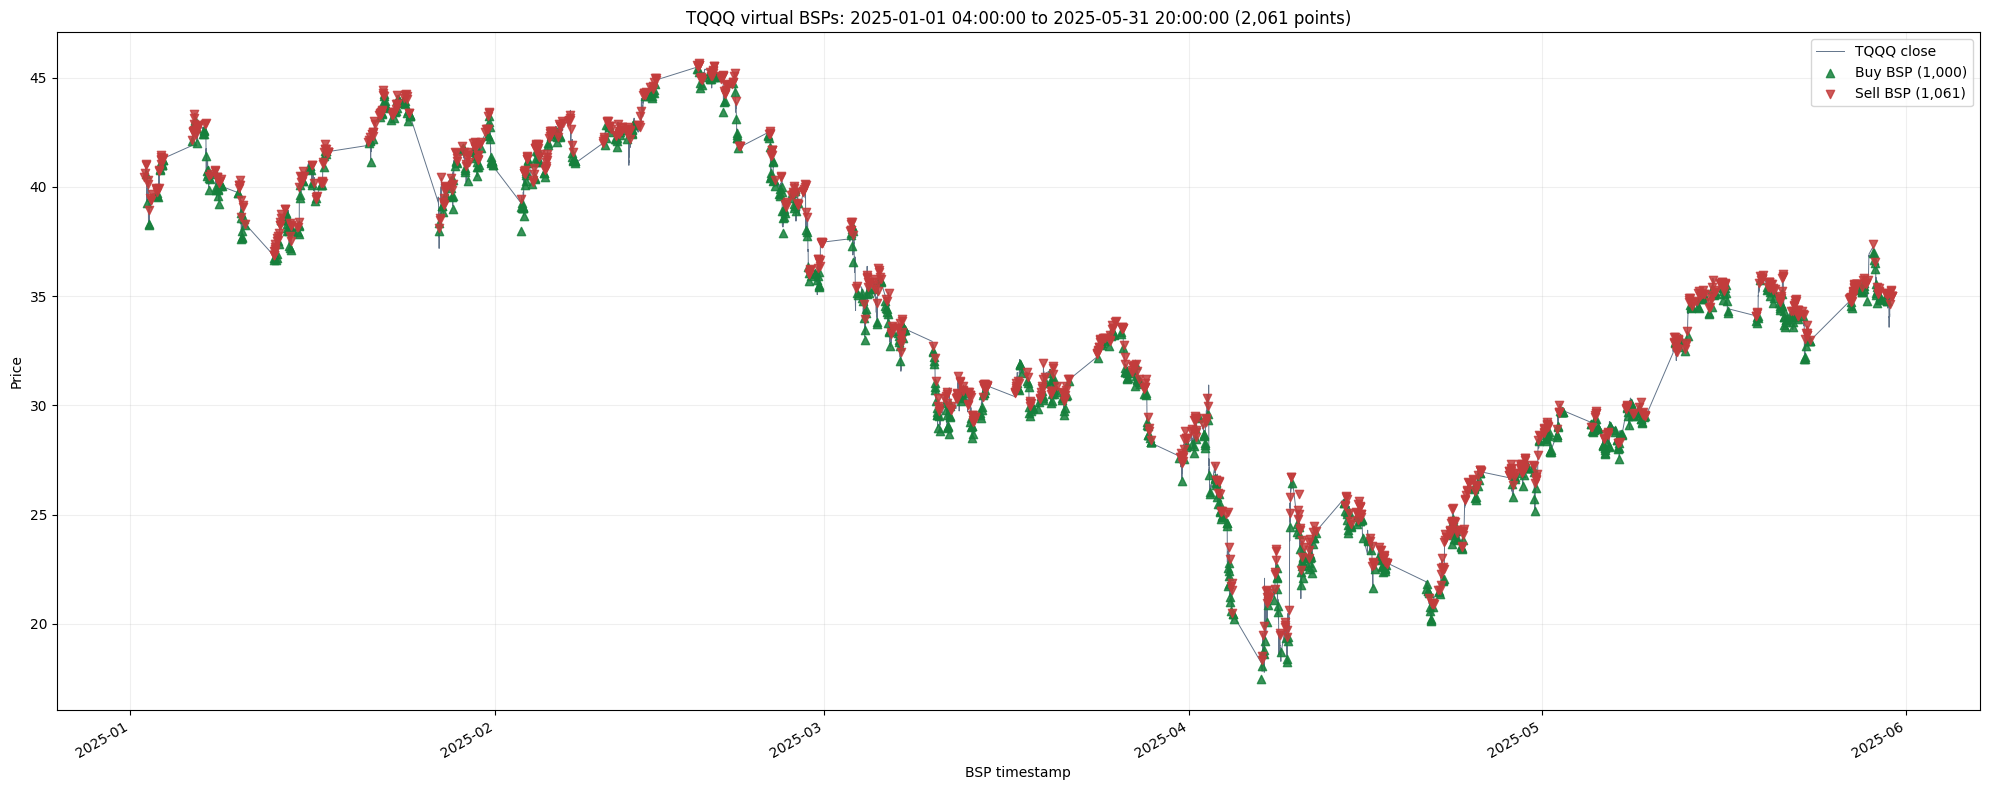

C:\Users\TonyTang\Documents\chan.py\outputs\TQQQ_virtual_bspoints_2020_01.png


In [8]:
from realistic_chan_simulation import (
    plot_virtual_bspoints_from_excel,
)

plot_path = plot_virtual_bspoints_from_excel(
    config,

    # Optional because config.bsp_workbook_path is already used by default.
    virtual_bsp_path=(
        "outputs/TQQQ_virtual_bsp_candidates.xlsx"
    ),

    path="outputs/TQQQ_virtual_bspoints_2020_01.png",

    start="2025-01-01 04:00:00",
    end="2025-05-31 20:00:00",

    show=True,
    annotate=False,
)

print(plot_path)

In [3]:
import importlib
import realistic_chan_simulation

importlib.reload(realistic_chan_simulation)

from realistic_chan_simulation import (
    plot_mature_bspoints_from_excel,
)

mature_plot_path = plot_mature_bspoints_from_excel(
    config,

    # This workbook must contain is_mature, is_mature_point, or mature_rate
    bsp_workbook_path=(
        "outputs/bspoints_TQQQ_5m_2020-2026_with_maturity.xlsx"
    ),

    path="outputs/TQQQ_mature_bspoints_2025.png",

    start="2025-01-01",
    end="2025-12-31 23:59:59",

    bsp_types=(
        "1",
        "1p",
        "2",
        "2s",
        "3a",
        "3b",
    ),

    direction=None,           # None, "buy", or "sell"
    minimum_mature_rate=1.0,
    annotate_types=True,
    max_background_points=75_000,
    show=True,
)

print(mature_plot_path)

FileNotFoundError: [Errno 2] No such file or directory: 'outputs\\bspoints_TQQQ_5m_2020-2026_with_maturity.xlsx'